# HOME CREDIT DEFAULT RISK PREDICTION

## IMPORTING DEPENDENCIES

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.ensemble import (RandomForestClassifier, GradientBoostingClassifier, AdaBoostClassifier)
from xgboost import XGBClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import RandomizedSearchCV
from lightgbm import LGBMClassifier
from sklearn.metrics import classification_report, roc_auc_score
from sklearn.metrics import accuracy_score,confusion_matrix,classification_report

import warnings
warnings.filterwarnings("ignore")

### LOAD DATASET

In [2]:
df = pd.read_csv("application_train.csv")
df

,SK_ID_CURR,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,...,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR
0,100002,1,Cash loans,M,N,Y,0,202500.0,406597.5,24700.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,1.0
1,100003,0,Cash loans,F,N,N,0,270000.0,1293502.5,35698.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
2,100004,0,Revolving loans,M,Y,Y,0,67500.0,135000.0,6750.0,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
3,100006,0,Cash loans,F,N,Y,0,135000.0,312682.5,29686.5,...,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
4,100007,0,Cash loans,M,N,Y,0,121500.0,513000.0,21865.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
307506,456251,0,Cash loans,M,N,N,0,157500.0,254700.0,27558.0,...,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
307507,456252,0,Cash loans,F,N,Y,0,72000.0,269550.0,12001.5,...,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
307508,456253,0,Cash loans,F,N,Y,0,153000.0,677664.0,29979.0,...,0,0,0,0,1.0,0.0,0.0,1.0,0.0,1.0
307509,456254,1,Cash loans,F,N,Y,0,171000.0,370107.0,20205.0,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0


## DATA UNDERSTANDING & INITIAL EXPLORATION

In [3]:
pd.set_option('display.max_columns', None)
df.head()

,SK_ID_CURR,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,AMT_GOODS_PRICE,NAME_TYPE_SUITE,NAME_INCOME_TYPE,NAME_EDUCATION_TYPE,NAME_FAMILY_STATUS,NAME_HOUSING_TYPE,REGION_POPULATION_RELATIVE,DAYS_BIRTH,DAYS_EMPLOYED,DAYS_REGISTRATION,DAYS_ID_PUBLISH,OWN_CAR_AGE,FLAG_MOBIL,FLAG_EMP_PHONE,FLAG_WORK_PHONE,FLAG_CONT_MOBILE,FLAG_PHONE,FLAG_EMAIL,OCCUPATION_TYPE,CNT_FAM_MEMBERS,REGION_RATING_CLIENT,REGION_RATING_CLIENT_W_CITY,WEEKDAY_APPR_PROCESS_START,HOUR_APPR_PROCESS_START,REG_REGION_NOT_LIVE_REGION,REG_REGION_NOT_WORK_REGION,LIVE_REGION_NOT_WORK_REGION,REG_CITY_NOT_LIVE_CITY,REG_CITY_NOT_WORK_CITY,LIVE_CITY_NOT_WORK_CITY,ORGANIZATION_TYPE,EXT_SOURCE_1,EXT_SOURCE_2,EXT_SOURCE_3,APARTMENTS_AVG,BASEMENTAREA_AVG,YEARS_BEGINEXPLUATATION_AVG,YEARS_BUILD_AVG,COMMONAREA_AVG,ELEVATORS_AVG,ENTRANCES_AVG,FLOORSMAX_AVG,FLOORSMIN_AVG,LANDAREA_AVG,LIVINGAPARTMENTS_AVG,LIVINGAREA_AVG,NONLIVINGAPARTMENTS_AVG,NONLIVINGAREA_AVG,APARTMENTS_MODE,BASEMENTAREA_MODE,YEARS_BEGINEXPLUATATION_MODE,YEARS_BUILD_MODE,COMMONAREA_MODE,ELEVATORS_MODE,ENTRANCES_MODE,FLOORSMAX_MODE,FLOORSMIN_MODE,LANDAREA_MODE,LIVINGAPARTMENTS_MODE,LIVINGAREA_MODE,NONLIVINGAPARTMENTS_MODE,NONLIVINGAREA_MODE,APARTMENTS_MEDI,BASEMENTAREA_MEDI,YEARS_BEGINEXPLUATATION_MEDI,YEARS_BUILD_MEDI,COMMONAREA_MEDI,ELEVATORS_MEDI,ENTRANCES_MEDI,FLOORSMAX_MEDI,FLOORSMIN_MEDI,LANDAREA_MEDI,LIVINGAPARTMENTS_MEDI,LIVINGAREA_MEDI,NONLIVINGAPARTMENTS_MEDI,NONLIVINGAREA_MEDI,FONDKAPREMONT_MODE,HOUSETYPE_MODE,TOTALAREA_MODE,WALLSMATERIAL_MODE,EMERGENCYSTATE_MODE,OBS_30_CNT_SOCIAL_CIRCLE,DEF_30_CNT_SOCIAL_CIRCLE,OBS_60_CNT_SOCIAL_CIRCLE,DEF_60_CNT_SOCIAL_CIRCLE,DAYS_LAST_PHONE_CHANGE,FLAG_DOCUMENT_2,FLAG_DOCUMENT_3,FLAG_DOCUMENT_4,FLAG_DOCUMENT_5,FLAG_DOCUMENT_6,FLAG_DOCUMENT_7,FLAG_DOCUMENT_8,FLAG_DOCUMENT_9,FLAG_DOCUMENT_10,FLAG_DOCUMENT_11,FLAG_DOCUMENT_12,FLAG_DOCUMENT_13,FLAG_DOCUMENT_14,FLAG_DOCUMENT_15,FLAG_DOCUMENT_16,FLAG_DOCUMENT_17,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR
0,100002,1,Cash loans,M,N,Y,0,202500.0,406597.5,24700.5,351000.0,Unaccompanied,Working,Secondary / secondary special,Single / not married,House / apartment,0.018801,-9461,-637,-3648.0,-2120,NaN,1,1,0,1,1,0,Laborers,1.0,2,2,WEDNESDAY,10,0,0,0,0,0,0,Business Entity Type 3,0.083037,0.262949,0.139376,0.0247,0.0369,0.9722,0.6192,0.0143,0.00,0.0690,0.0833,0.1250,0.0369,0.0202,0.0190,0.0000,0.0000,0.0252,0.0383,0.9722,0.6341,0.0144,0.0000,0.0690,0.0833,0.1250,0.0377,0.022,0.0198,0.0,0.0,0.0250,0.0369,0.9722,0.6243,0.0144,0.00,0.0690,0.0833,0.1250,0.0375,0.0205,0.0193,0.0000,0.00,reg oper account,block of flats,0.0149,"Stone, brick",No,2.0,2.0,2.0,2.0,-1134.0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.0,0.0,0.0,0.0,0.0,1.0
1,100003,0,Cash loans,F,N,N,0,270000.0,1293502.5,35698.5,1129500.0,Family,State servant,Higher education,Married,House / apartment,0.003541,-16765,-1188,-1186.0,-291,NaN,1,1,0,1,1,0,Core staff,2.0,1,1,MONDAY,11,0,0,0,0,0,0,School,0.311267,0.622246,NaN,0.0959,0.0529,0.9851,0.7960,0.0605,0.08,0.0345,0.2917,0.3333,0.0130,0.0773,0.0549,0.0039,0.0098,0.0924,0.0538,0.9851,0.8040,0.0497,0.0806,0.0345,0.2917,0.3333,0.0128,0.079,0.0554,0.0,0.0,0.0968,0.0529,0.9851,0.7987,0.0608,0.08,0.0345,0.2917,0.3333,0.0132,0.0787,0.0558,0.0039,0.01,reg oper account,block of flats,0.0714,Block,No,1.0,0.0,1.0,0.0,-828.0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
2,100004,0,Revolving loans,M,Y,Y,0,67500.0,135000.0,6750.0,135000.0,Unaccompanied,Working,Secondary / secondary special,Single / not married,House / apartment,0.010032,-19046,-225,-4260.0,-2531,26.0,1,1,1,1,1,0,Laborers,1.0,2,2,MONDAY,9,0,0,0,0,0,0,Government,NaN,0.555912,0.729567,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,

In [4]:
df.tail()

,SK_ID_CURR,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,AMT_GOODS_PRICE,NAME_TYPE_SUITE,NAME_INCOME_TYPE,NAME_EDUCATION_TYPE,NAME_FAMILY_STATUS,NAME_HOUSING_TYPE,REGION_POPULATION_RELATIVE,DAYS_BIRTH,DAYS_EMPLOYED,DAYS_REGISTRATION,DAYS_ID_PUBLISH,OWN_CAR_AGE,FLAG_MOBIL,FLAG_EMP_PHONE,FLAG_WORK_PHONE,FLAG_CONT_MOBILE,FLAG_PHONE,FLAG_EMAIL,OCCUPATION_TYPE,CNT_FAM_MEMBERS,REGION_RATING_CLIENT,REGION_RATING_CLIENT_W_CITY,WEEKDAY_APPR_PROCESS_START,HOUR_APPR_PROCESS_START,REG_REGION_NOT_LIVE_REGION,REG_REGION_NOT_WORK_REGION,LIVE_REGION_NOT_WORK_REGION,REG_CITY_NOT_LIVE_CITY,REG_CITY_NOT_WORK_CITY,LIVE_CITY_NOT_WORK_CITY,ORGANIZATION_TYPE,EXT_SOURCE_1,EXT_SOURCE_2,EXT_SOURCE_3,APARTMENTS_AVG,BASEMENTAREA_AVG,YEARS_BEGINEXPLUATATION_AVG,YEARS_BUILD_AVG,COMMONAREA_AVG,ELEVATORS_AVG,ENTRANCES_AVG,FLOORSMAX_AVG,FLOORSMIN_AVG,LANDAREA_AVG,LIVINGAPARTMENTS_AVG,LIVINGAREA_AVG,NONLIVINGAPARTMENTS_AVG,NONLIVINGAREA_AVG,APARTMENTS_MODE,BASEMENTAREA_MODE,YEARS_BEGINEXPLUATATION_MODE,YEARS_BUILD_MODE,COMMONAREA_MODE,ELEVATORS_MODE,ENTRANCES_MODE,FLOORSMAX_MODE,FLOORSMIN_MODE,LANDAREA_MODE,LIVINGAPARTMENTS_MODE,LIVINGAREA_MODE,NONLIVINGAPARTMENTS_MODE,NONLIVINGAREA_MODE,APARTMENTS_MEDI,BASEMENTAREA_MEDI,YEARS_BEGINEXPLUATATION_MEDI,YEARS_BUILD_MEDI,COMMONAREA_MEDI,ELEVATORS_MEDI,ENTRANCES_MEDI,FLOORSMAX_MEDI,FLOORSMIN_MEDI,LANDAREA_MEDI,LIVINGAPARTMENTS_MEDI,LIVINGAREA_MEDI,NONLIVINGAPARTMENTS_MEDI,NONLIVINGAREA_MEDI,FONDKAPREMONT_MODE,HOUSETYPE_MODE,TOTALAREA_MODE,WALLSMATERIAL_MODE,EMERGENCYSTATE_MODE,OBS_30_CNT_SOCIAL_CIRCLE,DEF_30_CNT_SOCIAL_CIRCLE,OBS_60_CNT_SOCIAL_CIRCLE,DEF_60_CNT_SOCIAL_CIRCLE,DAYS_LAST_PHONE_CHANGE,FLAG_DOCUMENT_2,FLAG_DOCUMENT_3,FLAG_DOCUMENT_4,FLAG_DOCUMENT_5,FLAG_DOCUMENT_6,FLAG_DOCUMENT_7,FLAG_DOCUMENT_8,FLAG_DOCUMENT_9,FLAG_DOCUMENT_10,FLAG_DOCUMENT_11,FLAG_DOCUMENT_12,FLAG_DOCUMENT_13,FLAG_DOCUMENT_14,FLAG_DOCUMENT_15,FLAG_DOCUMENT_16,FLAG_DOCUMENT_17,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR
307506,456251,0,Cash loans,M,N,N,0,157500.0,254700.0,27558.0,225000.0,Unaccompanied,Working,Secondary / secondary special,Separated,With parents,0.032561,-9327,-236,-8456.0,-1982,NaN,1,1,0,1,0,0,Sales staff,1.0,1,1,THURSDAY,15,0,0,0,0,0,0,Services,0.145570,0.681632,NaN,0.2021,0.0887,0.9876,0.8300,0.0202,0.22,0.1034,0.6042,0.2708,0.0594,0.1484,0.1965,0.0753,0.1095,0.1008,0.0172,0.9782,0.7125,0.0172,0.0806,0.0345,0.4583,0.0417,0.0094,0.0882,0.0853,0.0,0.0125,0.2040,0.0887,0.9876,0.8323,0.0203,0.22,0.1034,0.6042,0.2708,0.0605,0.1509,0.2001,0.0757,0.1118,reg oper account,block of flats,0.2898,"Stone, brick",No,0.0,0.0,0.0,0.0,-273.0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
307507,456252,0,Cash loans,F,N,Y,0,72000.0,269550.0,12001.5,225000.0,Unaccompanied,Pensioner,Secondary / secondary special,Widow,House / apartment,0.025164,-20775,365243,-4388.0,-4090,NaN,1,0,0,1,1,0,NaN,1.0,2,2,MONDAY,8,0,0,0,0,0,0,XNA,NaN,0.115992,NaN,0.0247,0.0435,0.9727,0.6260,0.0022,0.00,0.1034,0.0833,0.1250,0.0579,0.0202,0.0257,0.0000,0.0000,0.0252,0.0451,0.9727,0.6406,0.0022,0.0000,0.1034,0.0833,0.1250,0.0592,0.0220,0.0267,0.0,0.0000,0.0250,0.0435,0.9727,0.6310,0.0022,0.00,0.1034,0.0833,0.1250,0.0589,0.0205,0.0261,0.0000,0.0000,reg oper account,block of flats,0.0214,"Stone, brick",No,0.0,0.0,0.0,0.0,0.0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
307508,456253,0,Cash loans,F,N,Y,0,153000.0,677664.0,29979.0,585000.0,Unaccompanied,Working,Higher education,Separated,House / apartment,0.005002,-14966,-7921,-6737.0,-5150,NaN,1,1,0,1,0,1,Managers,1.0,3,3,THURSDAY,9,0,0,0,0,1,1,School,0.744026,0.535722,0.218859,0.1031,0.0862,0.9816,0.7484,0.0123,0.00,0.2069,0.1667,0.2083,NaN,0.0841,0.9279,0.0000,0.0000,0.1050,0.0894,0.9816,0.7583,0.0124,0.0000,0.2069,0.1667,0.2

In [5]:
df.shape

(307511, 122)

In [6]:
df.dtypes

SK_ID_CURR                      int64
TARGET                          int64
NAME_CONTRACT_TYPE             object
CODE_GENDER                    object
FLAG_OWN_CAR                   object
                               ...   
AMT_REQ_CREDIT_BUREAU_DAY     float64
AMT_REQ_CREDIT_BUREAU_WEEK    float64
AMT_REQ_CREDIT_BUREAU_MON     float64
AMT_REQ_CREDIT_BUREAU_QRT     float64
AMT_REQ_CREDIT_BUREAU_YEAR    float64
Length: 122, dtype: object

In [7]:
df.isna().sum()

SK_ID_CURR                        0
TARGET                            0
NAME_CONTRACT_TYPE                0
CODE_GENDER                       0
FLAG_OWN_CAR                      0
                              ...  
AMT_REQ_CREDIT_BUREAU_DAY     41519
AMT_REQ_CREDIT_BUREAU_WEEK    41519
AMT_REQ_CREDIT_BUREAU_MON     41519
AMT_REQ_CREDIT_BUREAU_QRT     41519
AMT_REQ_CREDIT_BUREAU_YEAR    41519
Length: 122, dtype: int64

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 307511 entries, 0 to 307510
Columns: 122 entries, SK_ID_CURR to AMT_REQ_CREDIT_BUREAU_YEAR
dtypes: float64(65), int64(41), object(16)
memory usage: 286.2+ MB


In [9]:
df.describe()

,SK_ID_CURR,TARGET,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,AMT_GOODS_PRICE,REGION_POPULATION_RELATIVE,DAYS_BIRTH,DAYS_EMPLOYED,DAYS_REGISTRATION,DAYS_ID_PUBLISH,OWN_CAR_AGE,FLAG_MOBIL,FLAG_EMP_PHONE,FLAG_WORK_PHONE,FLAG_CONT_MOBILE,FLAG_PHONE,FLAG_EMAIL,CNT_FAM_MEMBERS,REGION_RATING_CLIENT,REGION_RATING_CLIENT_W_CITY,HOUR_APPR_PROCESS_START,REG_REGION_NOT_LIVE_REGION,REG_REGION_NOT_WORK_REGION,LIVE_REGION_NOT_WORK_REGION,REG_CITY_NOT_LIVE_CITY,REG_CITY_NOT_WORK_CITY,LIVE_CITY_NOT_WORK_CITY,EXT_SOURCE_1,EXT_SOURCE_2,EXT_SOURCE_3,APARTMENTS_AVG,BASEMENTAREA_AVG,YEARS_BEGINEXPLUATATION_AVG,YEARS_BUILD_AVG,COMMONAREA_AVG,ELEVATORS_AVG,ENTRANCES_AVG,FLOORSMAX_AVG,FLOORSMIN_AVG,LANDAREA_AVG,LIVINGAPARTMENTS_AVG,LIVINGAREA_AVG,NONLIVINGAPARTMENTS_AVG,NONLIVINGAREA_AVG,APARTMENTS_MODE,BASEMENTAREA_MODE,YEARS_BEGINEXPLUATATION_MODE,YEARS_BUILD_MODE,COMMONAREA_MODE,ELEVATORS_MODE,ENTRANCES_MODE,FLOORSMAX_MODE,FLOORSMIN_MODE,LANDAREA_MODE,LIVINGAPARTMENTS_MODE,LIVINGAREA_MODE,NONLIVINGAPARTMENTS_MODE,NONLIVINGAREA_MODE,APARTMENTS_MEDI,BASEMENTAREA_MEDI,YEARS_BEGINEXPLUATATION_MEDI,YEARS_BUILD_MEDI,COMMONAREA_MEDI,ELEVATORS_MEDI,ENTRANCES_MEDI,FLOORSMAX_MEDI,FLOORSMIN_MEDI,LANDAREA_MEDI,LIVINGAPARTMENTS_MEDI,LIVINGAREA_MEDI,NONLIVINGAPARTMENTS_MEDI,NONLIVINGAREA_MEDI,TOTALAREA_MODE,OBS_30_CNT_SOCIAL_CIRCLE,DEF_30_CNT_SOCIAL_CIRCLE,OBS_60_CNT_SOCIAL_CIRCLE,DEF_60_CNT_SOCIAL_CIRCLE,DAYS_LAST_PHONE_CHANGE,FLAG_DOCUMENT_2,FLAG_DOCUMENT_3,FLAG_DOCUMENT_4,FLAG_DOCUMENT_5,FLAG_DOCUMENT_6,FLAG_DOCUMENT_7,FLAG_DOCUMENT_8,FLAG_DOCUMENT_9,FLAG_DOCUMENT_10,FLAG_DOCUMENT_11,FLAG_DOCUMENT_12,FLAG_DOCUMENT_13,FLAG_DOCUMENT_14,FLAG_DOCUMENT_15,FLAG_DOCUMENT_16,FLAG_DOCUMENT_17,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR
count,307511.000000,307511.000000,307511.000000,3.075110e+05,3.075110e+05,307499.000000,3.072330e+05,307511.000000,307511.000000,307511.000000,307511.000000,307511.000000,104582.000000,307511.000000,307511.000000,307511.000000,307511.000000,307511.000000,307511.000000,307509.000000,307511.000000,307511.000000,307511.000000,307511.000000,307511.000000,307511.000000,307511.000000,307511.000000,307511.000000,134133.000000,3.068510e+05,246546.000000,151450.00000,127568.000000,157504.000000,103023.000000,92646.000000,143620.000000,152683.000000,154491.000000,98869.000000,124921.000000,97312.000000,153161.000000,93997.000000,137829.000000,151450.000000,127568.000000,157504.000000,103023.000000,92646.000000,143620.000000,152683.000000,154491.000000,98869.000000,124921.000000,97312.000000,153161.000000,93997.000000,137829.000000,151450.000000,127568.000000,157504.000000,103023.000000,92646.000000,143620.000000,152683.000000,154491.000000,98869.000000,124921.000000,97312.000000,153161.000000,93997.000000,137829.000000,159080.000000,306490.000000,306490.000000,306490.000000,306490.000000,307510.000000,307511.000000,307511.000000,307511.000000,307511.000000,307511.000000,307511.000000,307511.000000,307511.000000,307511.000000,307511.000000,307511.000000,307511.000000,307511.000000,307511.00000,307511.000000,307511.000000,307511.000000,307511.000000,307511.000000,307511.000000,265992.000000,265992.000000,265992.000000,265992.000000,265992.000000,265992.000000
mean,278180.518577,0.080729,0.417052,1.687979e+05,5.990260e+05,27108.573909,5.383962e+05,0.020868,-16036.995067,63815.045904,-4986.120328,-2994.202373,12.061091,0.999997,0.819889,0.199368,0.998133,0.281066,0.056720,2.152665,2.052463,2.031521,12.063419,0.015144,0.050769,0.040659,0.078173,0.230454,0.179555,0.502130,5.143927e-01,0.510853,0.11744,0.088442,0.977735,0.752471,0.044621,0.078942,0.149725,0.226282,0.231894,0.066333,0.100775,0.107399,0.008809,0.028358,0.114231,0.087543,0.977065,0.759637,0.042553,0.074490,0.145193,0.222315,0.228058,0.064958,0.105645,0.105975,0.008076,0.027022,0.117850,0.087955,0.97

In [10]:
df.duplicated().sum()

np.int64(0)

In [11]:
df.nunique()

SK_ID_CURR                    307511
TARGET                             2
NAME_CONTRACT_TYPE                 2
CODE_GENDER                        3
FLAG_OWN_CAR                       2
                               ...  
AMT_REQ_CREDIT_BUREAU_DAY          9
AMT_REQ_CREDIT_BUREAU_WEEK         9
AMT_REQ_CREDIT_BUREAU_MON         24
AMT_REQ_CREDIT_BUREAU_QRT         11
AMT_REQ_CREDIT_BUREAU_YEAR        25
Length: 122, dtype: int64

In [12]:
df['TARGET'].value_counts()

TARGET
0    282686
1     24825
Name: count, dtype: int64

## EXPLORATORY DATA ANALYSIS (EDA)

### TARGET COUNT PLOT

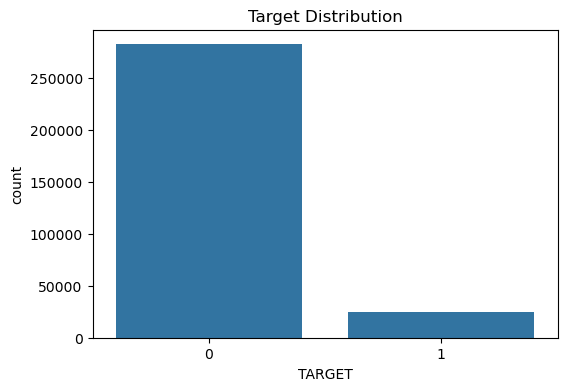

In [13]:
plt.figure(figsize=(6,4))
sns.countplot(x='TARGET', data=df)
plt.title("Target Distribution")
plt.show()

### MISSING VALUE PERCENTAGE

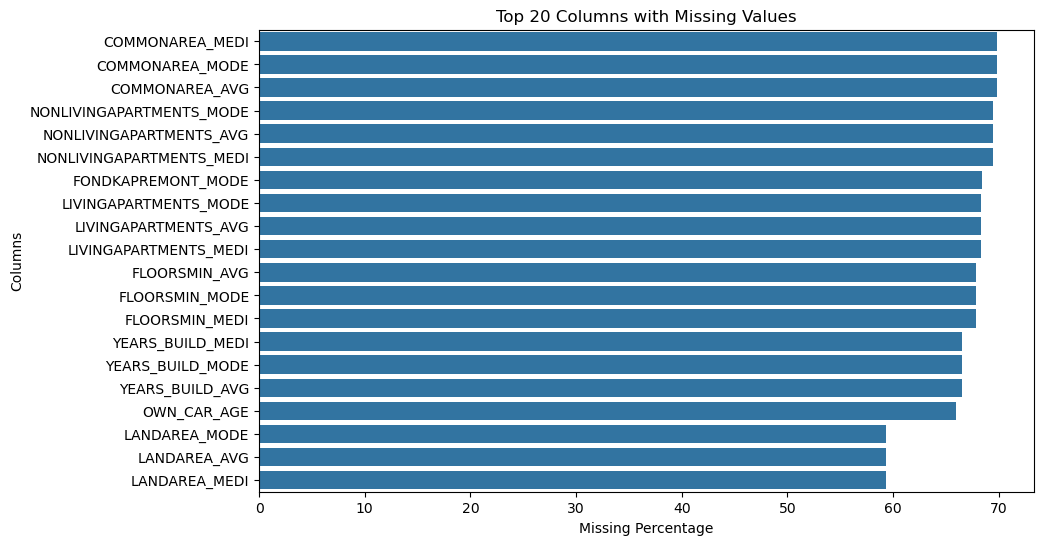

In [14]:
missing = df.isnull().sum().sort_values(ascending=False)
missing_percent = (missing / len(df)) * 100
missing_df = pd.DataFrame({
    'Missing Count': missing,
    'Missing Percentage': missing_percent
})
missing_df[missing_df['Missing Count'] > 0].head(20)

missing_plot = missing_df[missing_df['Missing Percentage'] > 0].sort_values(
    by='Missing Percentage', ascending=False
).head(20)

plt.figure(figsize=(10,6))
sns.barplot(x=missing_plot['Missing Percentage'], y=missing_plot.index)
plt.title("Top 20 Columns with Missing Values")
plt.xlabel("Missing Percentage")
plt.ylabel("Columns")
plt.show()

### NUMERICAL FEATURE DISTRIBUTION

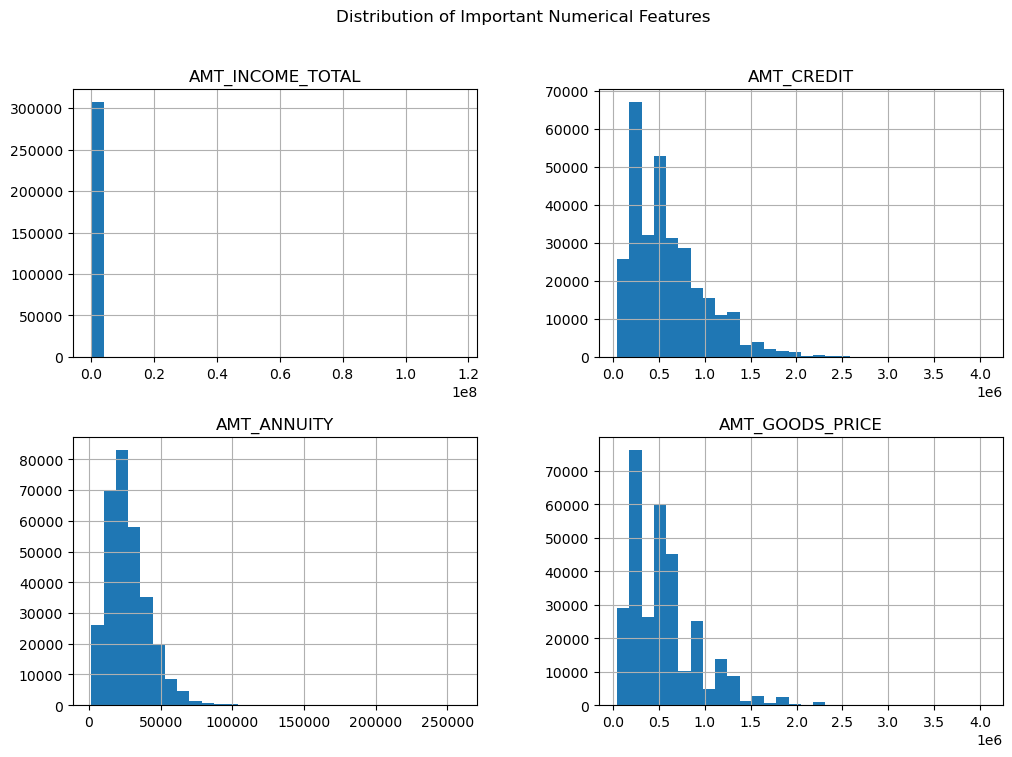

In [15]:
num_features = ['AMT_INCOME_TOTAL', 'AMT_CREDIT', 'AMT_ANNUITY', 'AMT_GOODS_PRICE']

df[num_features].hist(figsize=(12,8), bins=30)
plt.suptitle("Distribution of Important Numerical Features")
plt.show()

### TARGET VS INCOME TYPE

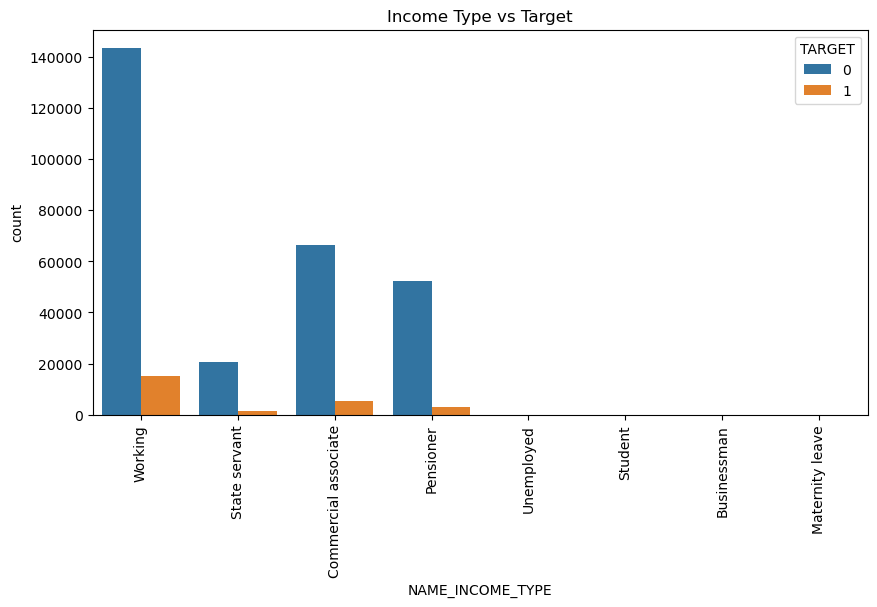

In [16]:
plt.figure(figsize=(10,5))
sns.countplot(data=df, x='NAME_INCOME_TYPE', hue='TARGET')
plt.xticks(rotation=90)
plt.title("Income Type vs Target")
plt.show()

### TARGET VS EDUCATION

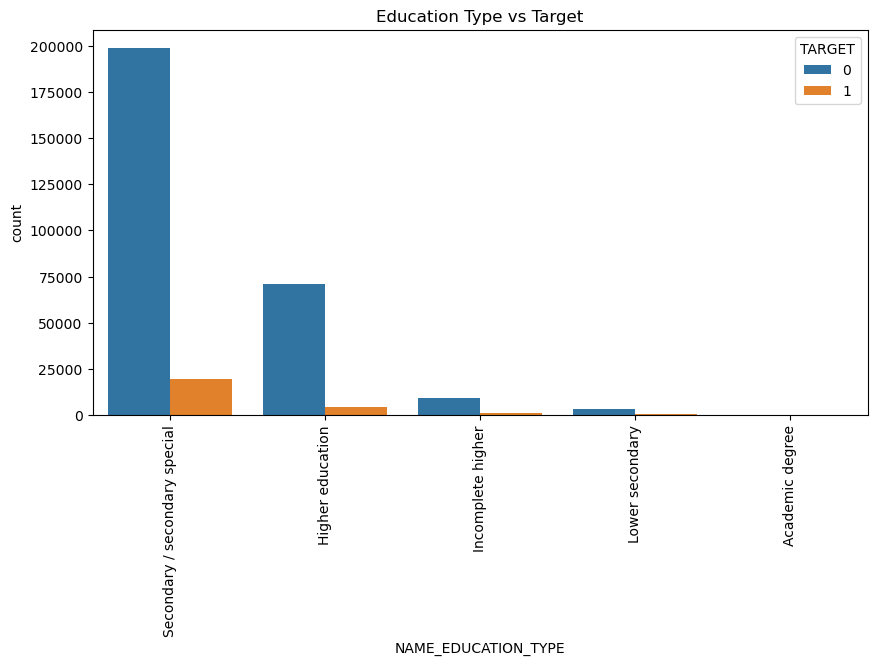

In [17]:
plt.figure(figsize=(10,5))
sns.countplot(data=df, x='NAME_EDUCATION_TYPE', hue='TARGET')
plt.xticks(rotation=90)
plt.title("Education Type vs Target")
plt.show()

### AGE DISTRIBUTION

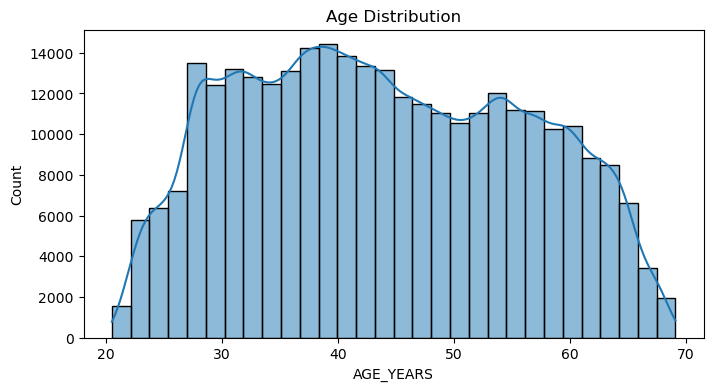

In [18]:
df['AGE_YEARS'] = abs(df['DAYS_BIRTH']) / 365

plt.figure(figsize=(8,4))
sns.histplot(df['AGE_YEARS'], bins=30, kde=True)
plt.title("Age Distribution")
plt.show()

### BOXPLOTS FOR OUTLIERS

<Figure size 1500x1500 with 0 Axes>

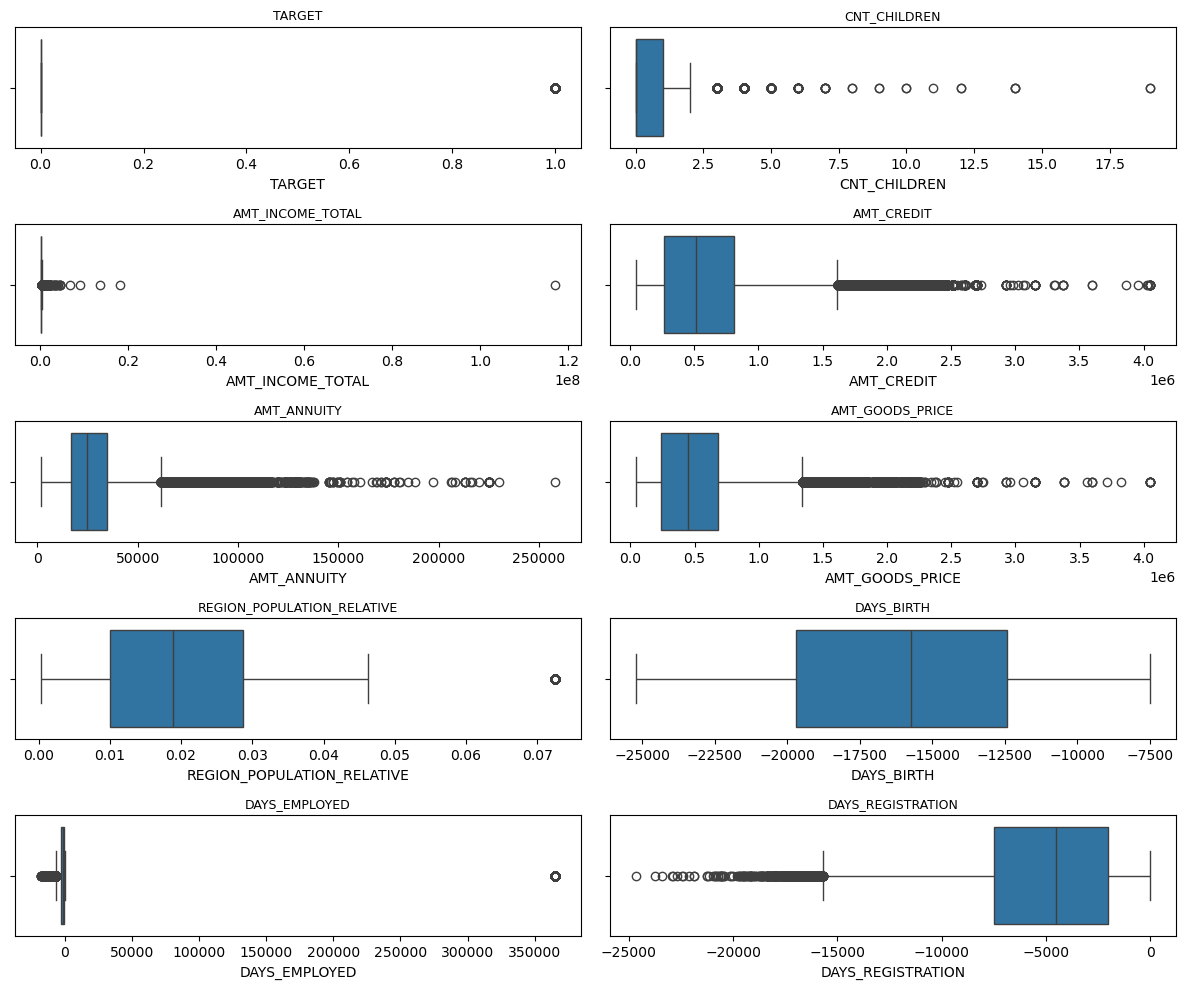

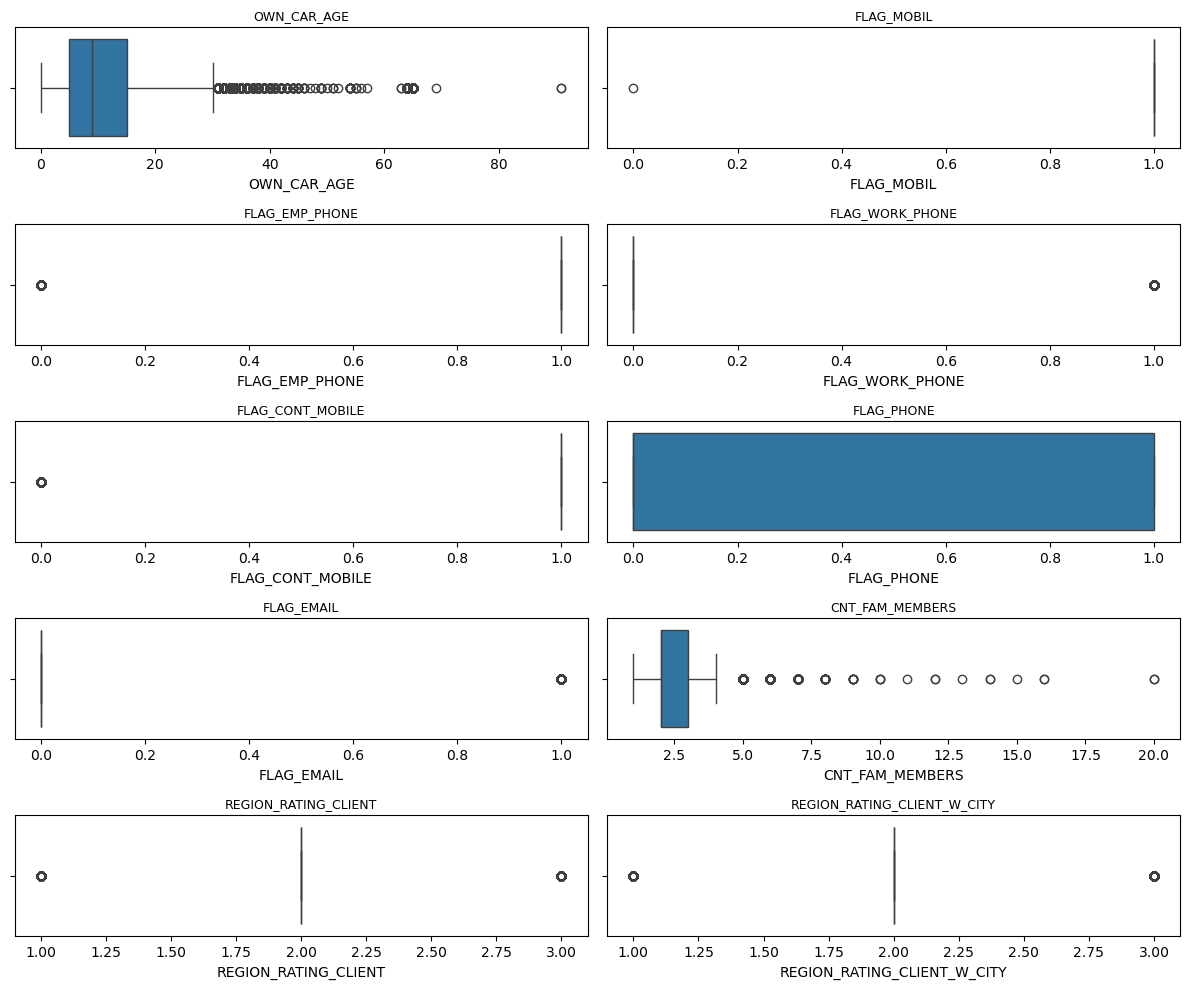

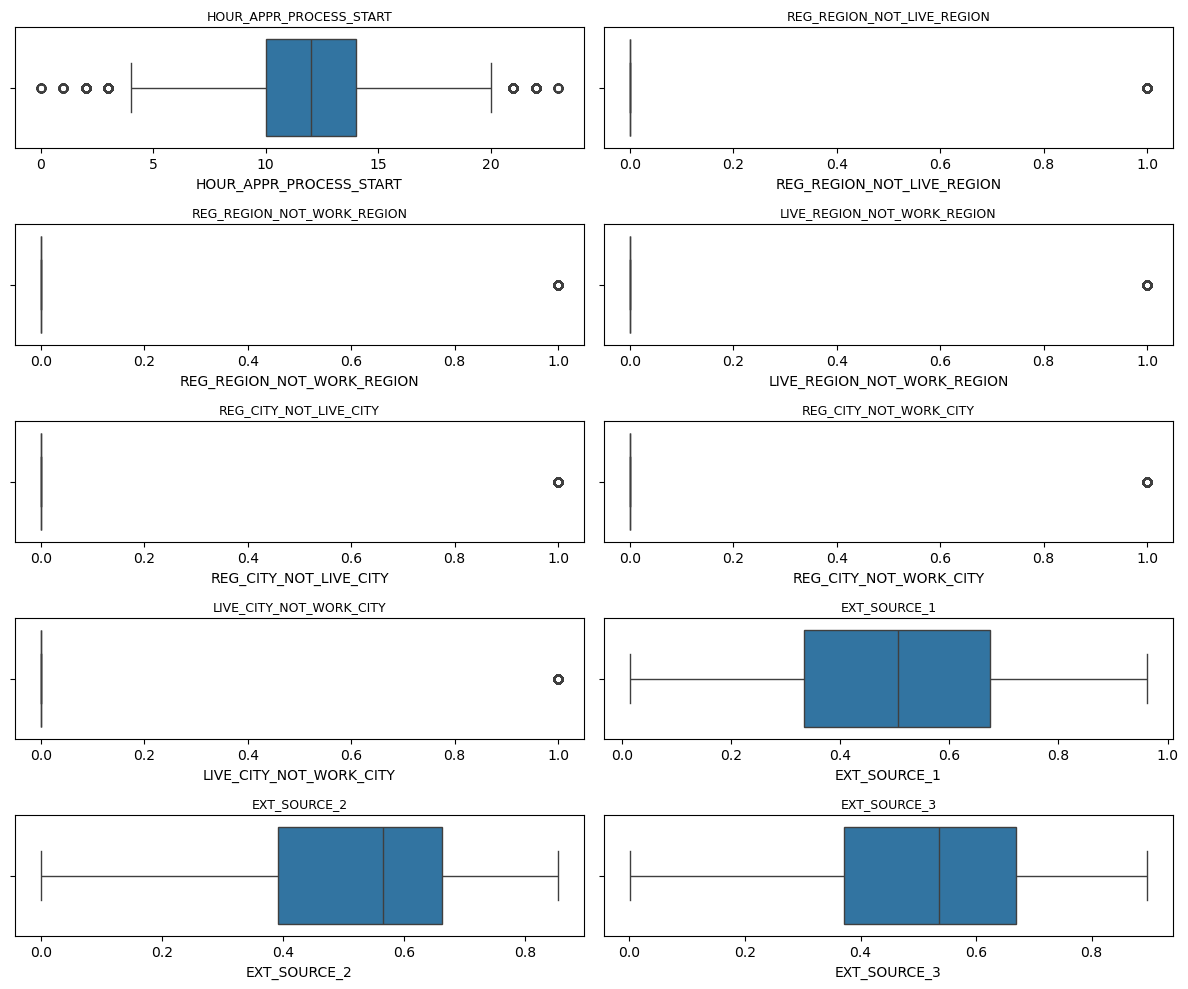

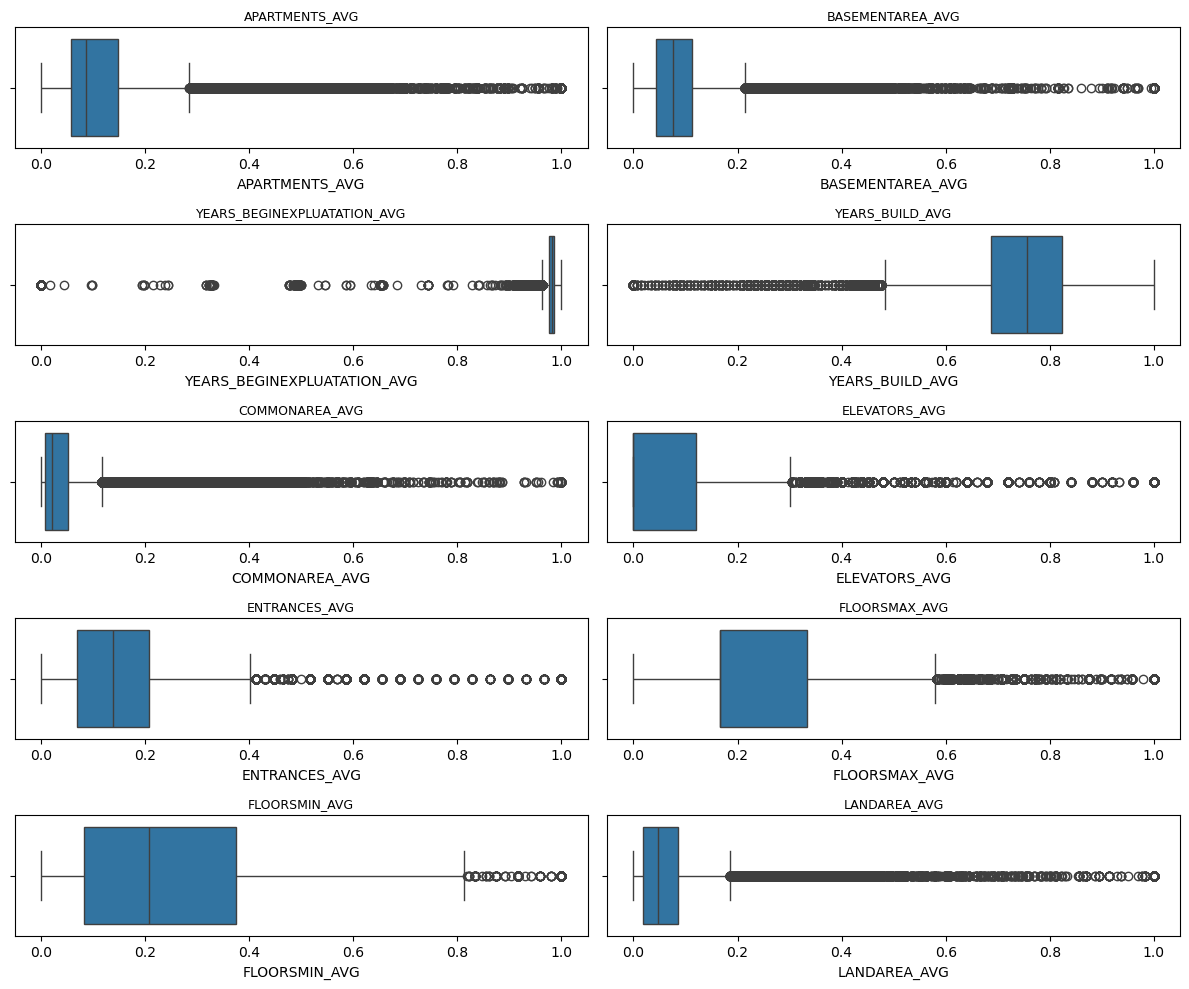

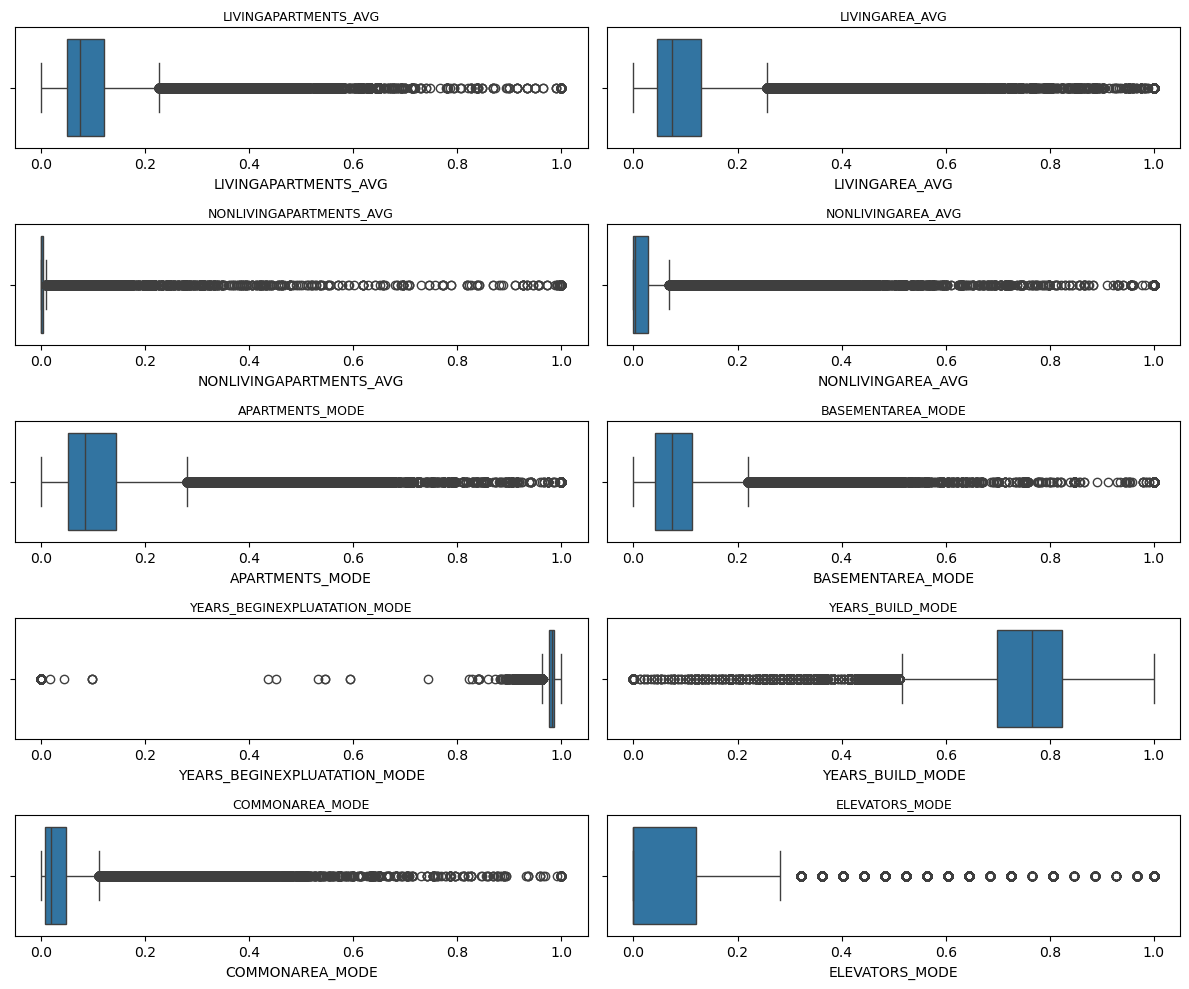

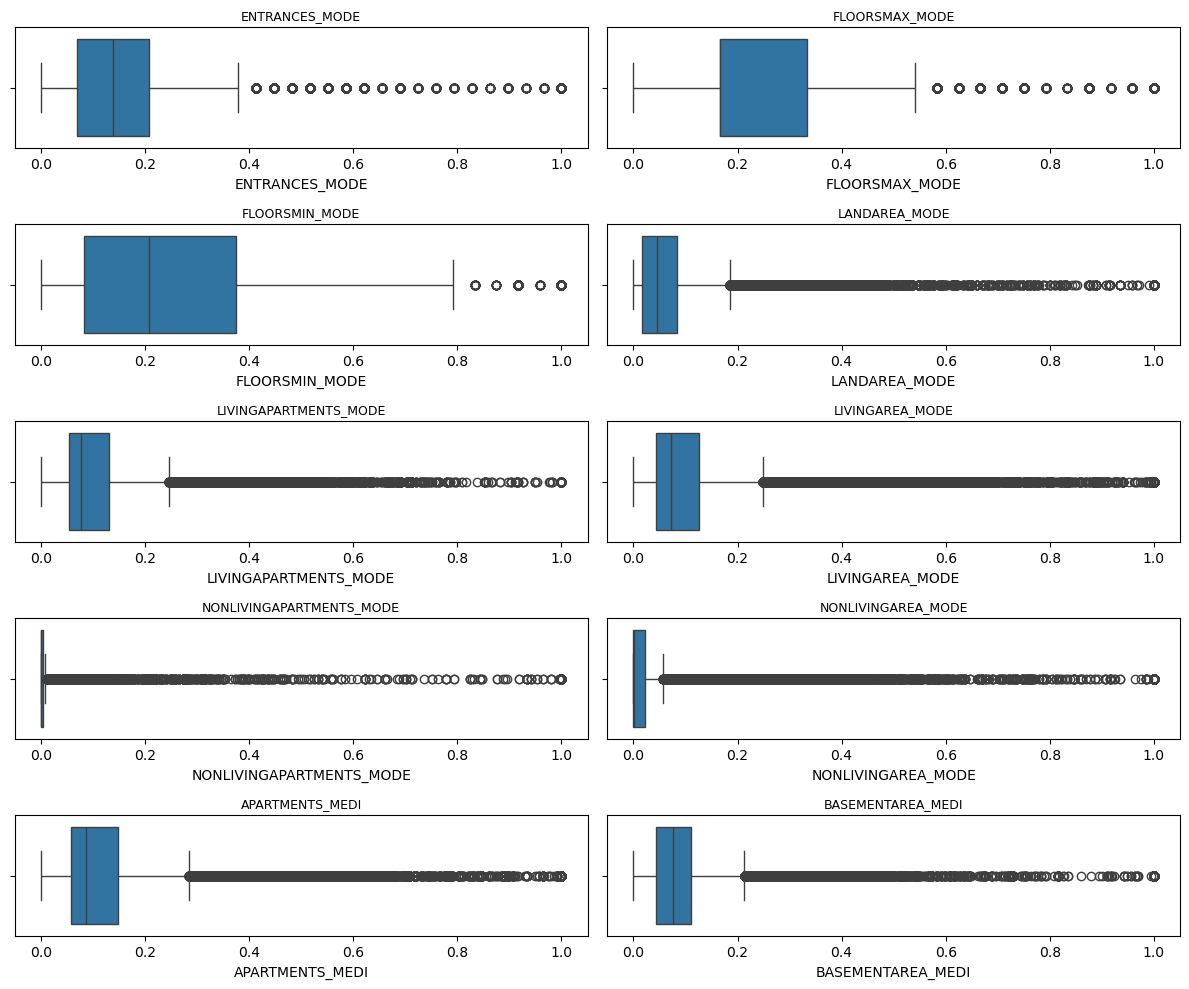

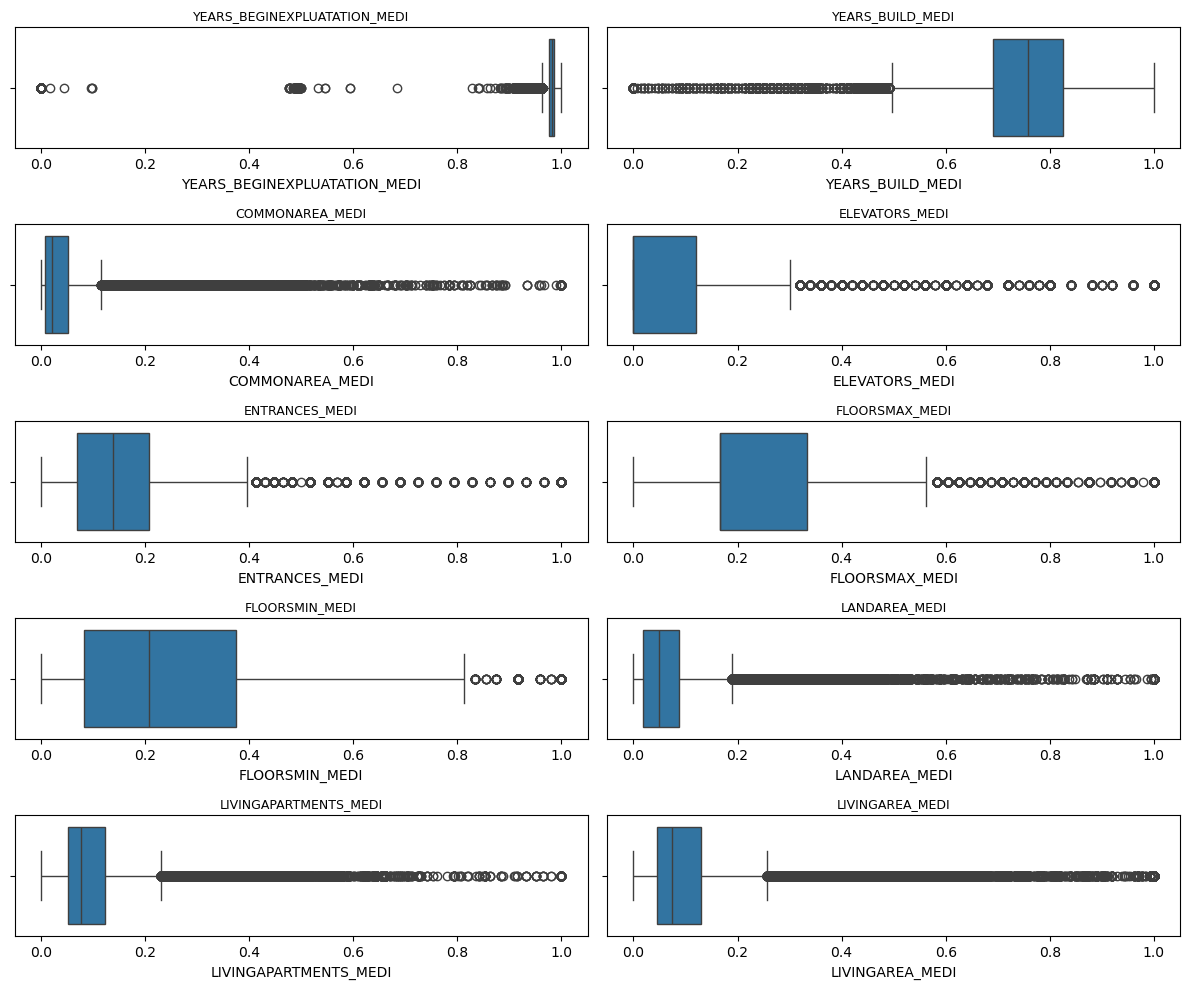

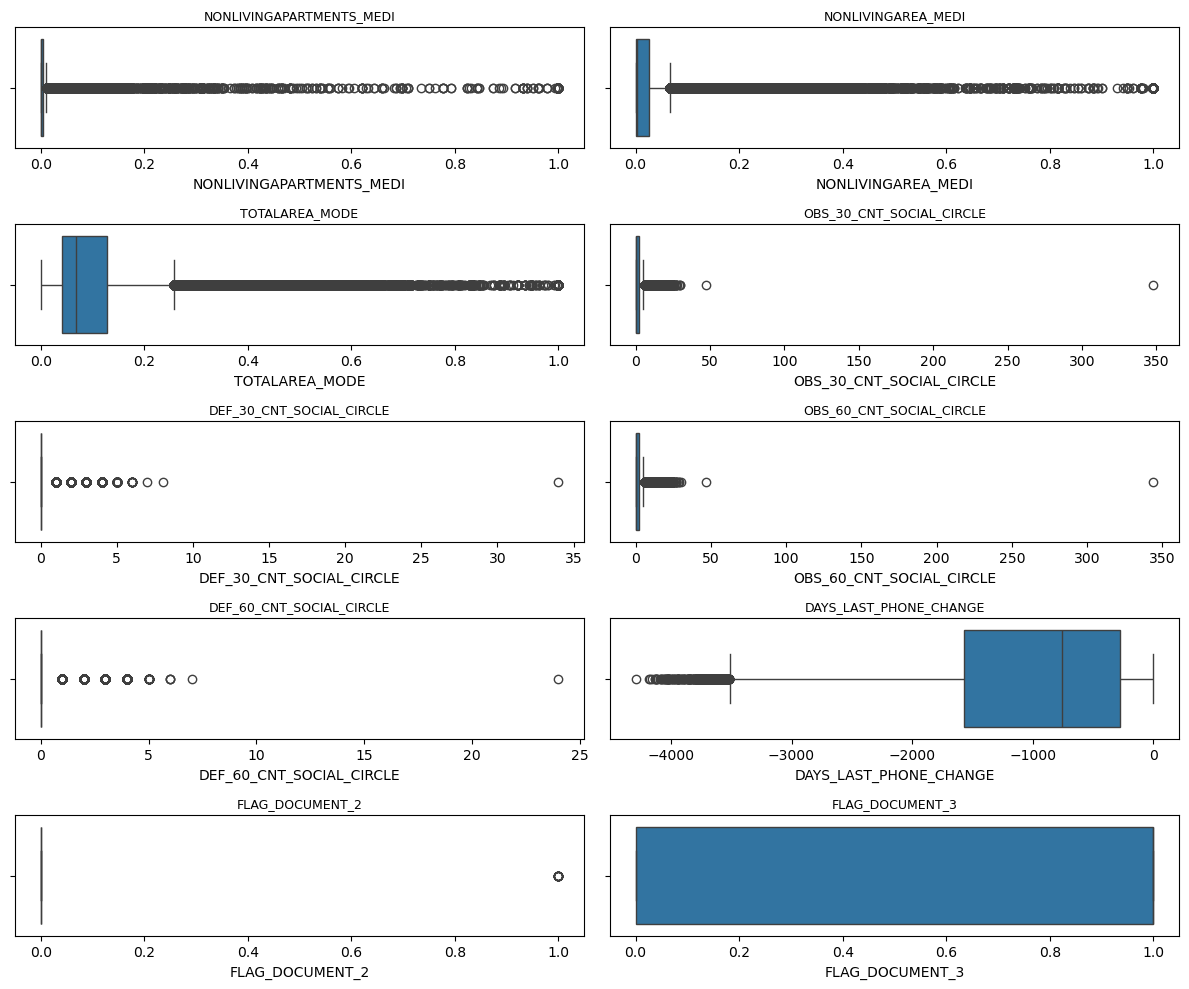

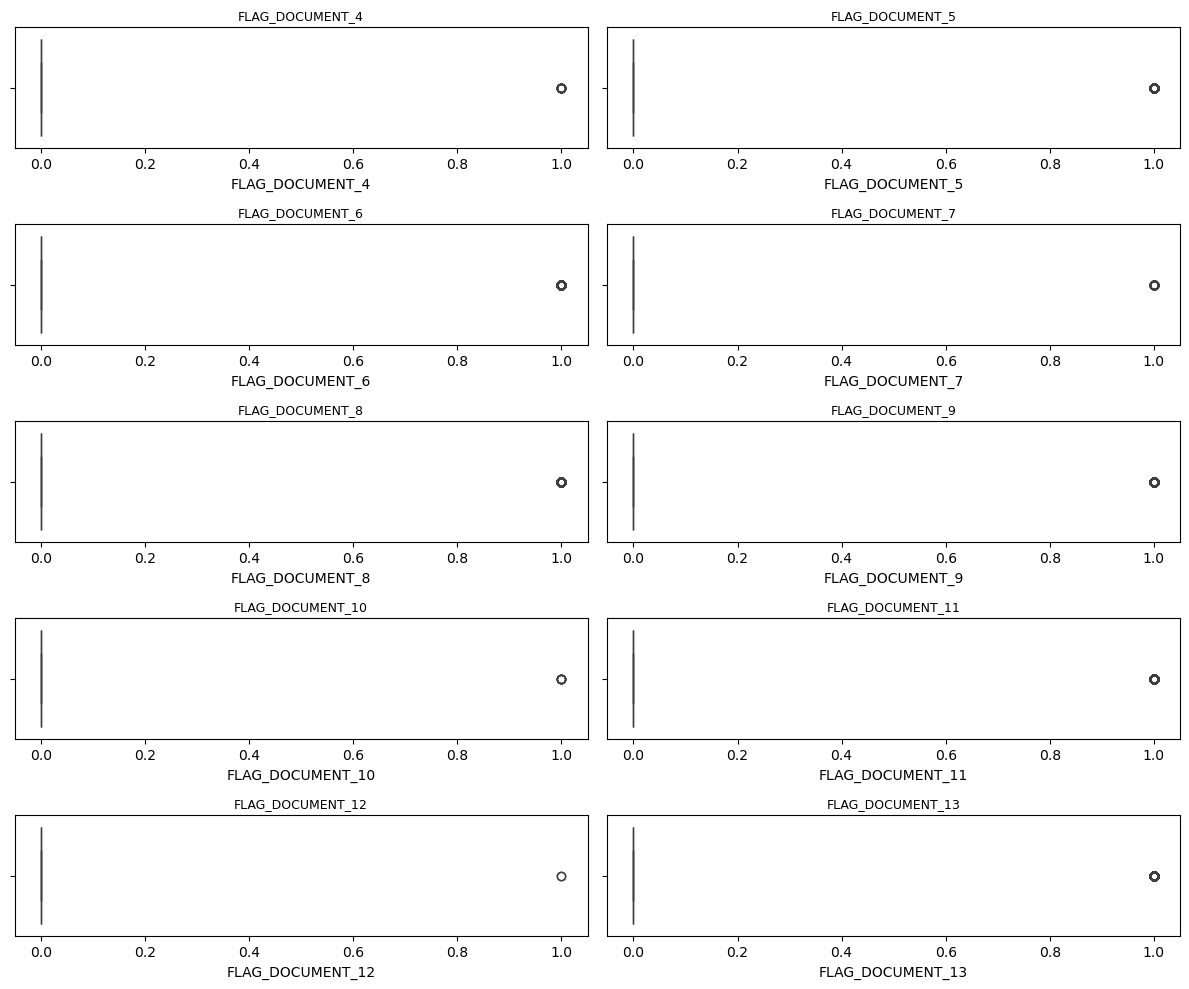

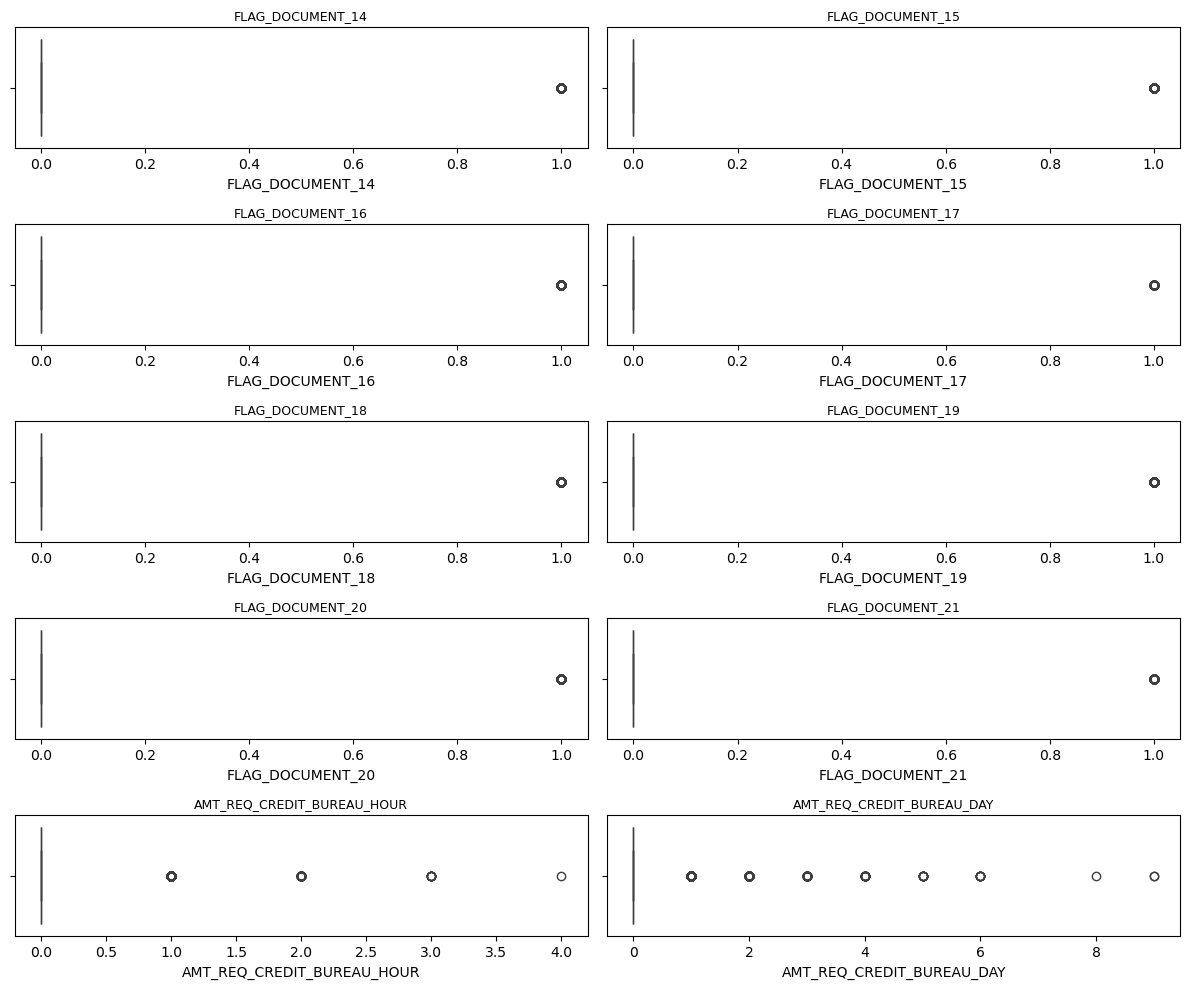

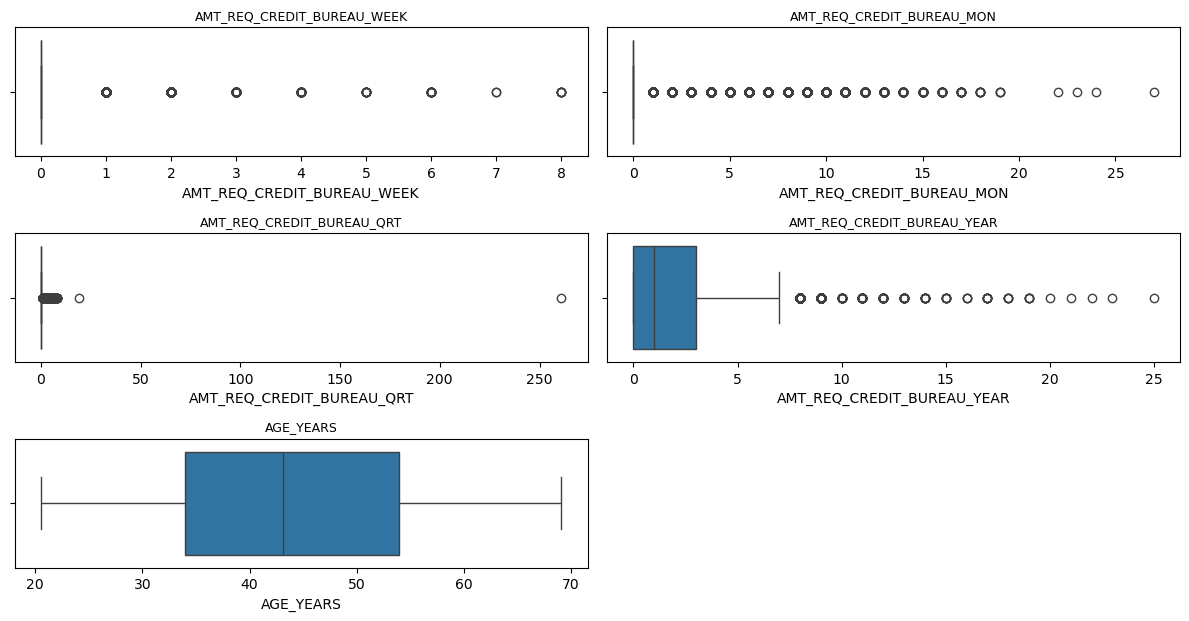

In [19]:
numcol = df.select_dtypes(include=['int64','float64']).columns
numcol = [col for col in numcol if 'ID' not in col]

batch_size = 10

plt.figure(figsize=(15,15), layout='constrained')

for i in range(0,len(numcol),batch_size):
    subset = numcol[i:i+batch_size]
    plt.figure(figsize=(12,10))
    for j, col in enumerate(subset):
        plt.subplot(5,2, j + 1)
        sns.boxplot(x=df[col])
        plt.title(col, fontsize=9) 
        
    plt.tight_layout()
    plt.show()

## DATA PREPROCESSING 

In [20]:
df = df.drop(columns=['SK_ID_CURR'])

### REMOVE HIGHLY MISSING COLUMNS

In [21]:
missing_threshold = 0.4
missing_ratio = df.isnull().mean()
drop_cols = missing_ratio[missing_ratio > missing_threshold].index.tolist()

df = df.drop(columns=drop_cols)
print("Dropped columns:", len(drop_cols))
print(df.shape)

Dropped columns: 49
(307511, 73)


### HANDLE MISSING VALES

In [22]:
num_cols = df.select_dtypes(include=['int64','float64']).columns
cat_cols = df.select_dtypes(include=['object']).columns

In [23]:
df[num_cols] = df[num_cols].fillna(df[num_cols].median())
df[cat_cols] = df[cat_cols].fillna("Unknown")

### OUTLIER HANDLING

In [24]:
df.columns

Index(['TARGET', 'NAME_CONTRACT_TYPE', 'CODE_GENDER', 'FLAG_OWN_CAR',
       'FLAG_OWN_REALTY', 'CNT_CHILDREN', 'AMT_INCOME_TOTAL', 'AMT_CREDIT',
       'AMT_ANNUITY', 'AMT_GOODS_PRICE', 'NAME_TYPE_SUITE', 'NAME_INCOME_TYPE',
       'NAME_EDUCATION_TYPE', 'NAME_FAMILY_STATUS', 'NAME_HOUSING_TYPE',
       'REGION_POPULATION_RELATIVE', 'DAYS_BIRTH', 'DAYS_EMPLOYED',
       'DAYS_REGISTRATION', 'DAYS_ID_PUBLISH', 'FLAG_MOBIL', 'FLAG_EMP_PHONE',
       'FLAG_WORK_PHONE', 'FLAG_CONT_MOBILE', 'FLAG_PHONE', 'FLAG_EMAIL',
       'OCCUPATION_TYPE', 'CNT_FAM_MEMBERS', 'REGION_RATING_CLIENT',
       'REGION_RATING_CLIENT_W_CITY', 'WEEKDAY_APPR_PROCESS_START',
       'HOUR_APPR_PROCESS_START', 'REG_REGION_NOT_LIVE_REGION',
       'REG_REGION_NOT_WORK_REGION', 'LIVE_REGION_NOT_WORK_REGION',
       'REG_CITY_NOT_LIVE_CITY', 'REG_CITY_NOT_WORK_CITY',
       'LIVE_CITY_NOT_WORK_CITY', 'ORGANIZATION_TYPE', 'EXT_SOURCE_2',
       'EXT_SOURCE_3', 'OBS_30_CNT_SOCIAL_CIRCLE', 'DEF_30_CNT_SOCIAL_CIRCLE',
  

In [25]:
df.head()

,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,AMT_GOODS_PRICE,NAME_TYPE_SUITE,NAME_INCOME_TYPE,NAME_EDUCATION_TYPE,NAME_FAMILY_STATUS,NAME_HOUSING_TYPE,REGION_POPULATION_RELATIVE,DAYS_BIRTH,DAYS_EMPLOYED,DAYS_REGISTRATION,DAYS_ID_PUBLISH,FLAG_MOBIL,FLAG_EMP_PHONE,FLAG_WORK_PHONE,FLAG_CONT_MOBILE,FLAG_PHONE,FLAG_EMAIL,OCCUPATION_TYPE,CNT_FAM_MEMBERS,REGION_RATING_CLIENT,REGION_RATING_CLIENT_W_CITY,WEEKDAY_APPR_PROCESS_START,HOUR_APPR_PROCESS_START,REG_REGION_NOT_LIVE_REGION,REG_REGION_NOT_WORK_REGION,LIVE_REGION_NOT_WORK_REGION,REG_CITY_NOT_LIVE_CITY,REG_CITY_NOT_WORK_CITY,LIVE_CITY_NOT_WORK_CITY,ORGANIZATION_TYPE,EXT_SOURCE_2,EXT_SOURCE_3,OBS_30_CNT_SOCIAL_CIRCLE,DEF_30_CNT_SOCIAL_CIRCLE,OBS_60_CNT_SOCIAL_CIRCLE,DEF_60_CNT_SOCIAL_CIRCLE,DAYS_LAST_PHONE_CHANGE,FLAG_DOCUMENT_2,FLAG_DOCUMENT_3,FLAG_DOCUMENT_4,FLAG_DOCUMENT_5,FLAG_DOCUMENT_6,FLAG_DOCUMENT_7,FLAG_DOCUMENT_8,FLAG_DOCUMENT_9,FLAG_DOCUMENT_10,FLAG_DOCUMENT_11,FLAG_DOCUMENT_12,FLAG_DOCUMENT_13,FLAG_DOCUMENT_14,FLAG_DOCUMENT_15,FLAG_DOCUMENT_16,FLAG_DOCUMENT_17,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR,AGE_YEARS
0,1,Cash loans,M,N,Y,0,202500.0,406597.5,24700.5,351000.0,Unaccompanied,Working,Secondary / secondary special,Single / not married,House / apartment,0.018801,-9461,-637,-3648.0,-2120,1,1,0,1,1,0,Laborers,1.0,2,2,WEDNESDAY,10,0,0,0,0,0,0,Business Entity Type 3,0.262949,0.139376,2.0,2.0,2.0,2.0,-1134.0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.0,0.0,0.0,0.0,0.0,1.0,25.920548
1,0,Cash loans,F,N,N,0,270000.0,1293502.5,35698.5,1129500.0,Family,State servant,Higher education,Married,House / apartment,0.003541,-16765,-1188,-1186.0,-291,1,1,0,1,1,0,Core staff,2.0,1,1,MONDAY,11,0,0,0,0,0,0,School,0.622246,0.535276,1.0,0.0,1.0,0.0,-828.0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0,45.931507
2,0,Revolving loans,M,Y,Y,0,67500.0,135000.0,6750.0,135000.0,Unaccompanied,Working,Secondary / secondary special,Single / not married,House / apartment,0.010032,-19046,-225,-4260.0,-2531,1,1,1,1,1,0,Laborers,1.0,2,2,MONDAY,9,0,0,0,0,0,0,Government,0.555912,0.729567,0.0,0.0,0.0,0.0,-815.0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0,52.180822
3,0,Cash loans,F,N,Y,0,135000.0,312682.5,29686.5,297000.0,Unaccompanied,Working,Secondary / secondary special,Civil marriage,House / apartment,0.008019,-19005,-3039,-9833.0,-2437,1,1,0,1,0,0,Laborers,2.0,2,2,WEDNESDAY,17,0,0,0,0,0,0,Business Entity Type 3,0.650442,0.535276,2.0,0.0,2.0,0.0,-617.0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.0,0.0,0.0,0.0,0.0,1.0,52.068493
4,0,Cash loans,M,N,Y,0,121500.0,513000.0,21865.5,513000.0,Unaccompanied,Working,Secondary / secondary special,Single / not married,House / apartment,0.028663,-19932,-3038,-4311.0,-3458,1,1,0,1,0,0,Core staff,1.0,2,2,THURSDAY,11,0,0,0,0,1,1,Religion,0.322738,0.535276,0.0,0.0,0.0,0.0,-1106.0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0,54.608219


Outlier Summary Before Handling:
                  Feature  Outlier_Count_Before   Lower_Bound  Upper_Bound
5           DAYS_EMPLOYED                 15149  -6787.000000  2845.000000
0        AMT_INCOME_TOTAL                  6591     10.749043    13.100174
9         CNT_FAM_MEMBERS                  4007      0.500000     4.500000
2             AMT_ANNUITY                  2244      8.604291    11.559861
3         AMT_GOODS_PRICE                  1345     10.811651    14.999592
1              AMT_CREDIT                   954     10.860768    15.248535
6       DAYS_REGISTRATION                   659 -15683.750000  6194.250000
8  DAYS_LAST_PHONE_CHANGE                   435  -3514.000000  1670.000000
4              DAYS_BIRTH                     0 -30585.500000 -1509.500000
7         DAYS_ID_PUBLISH                     0  -8167.500000  2148.500000


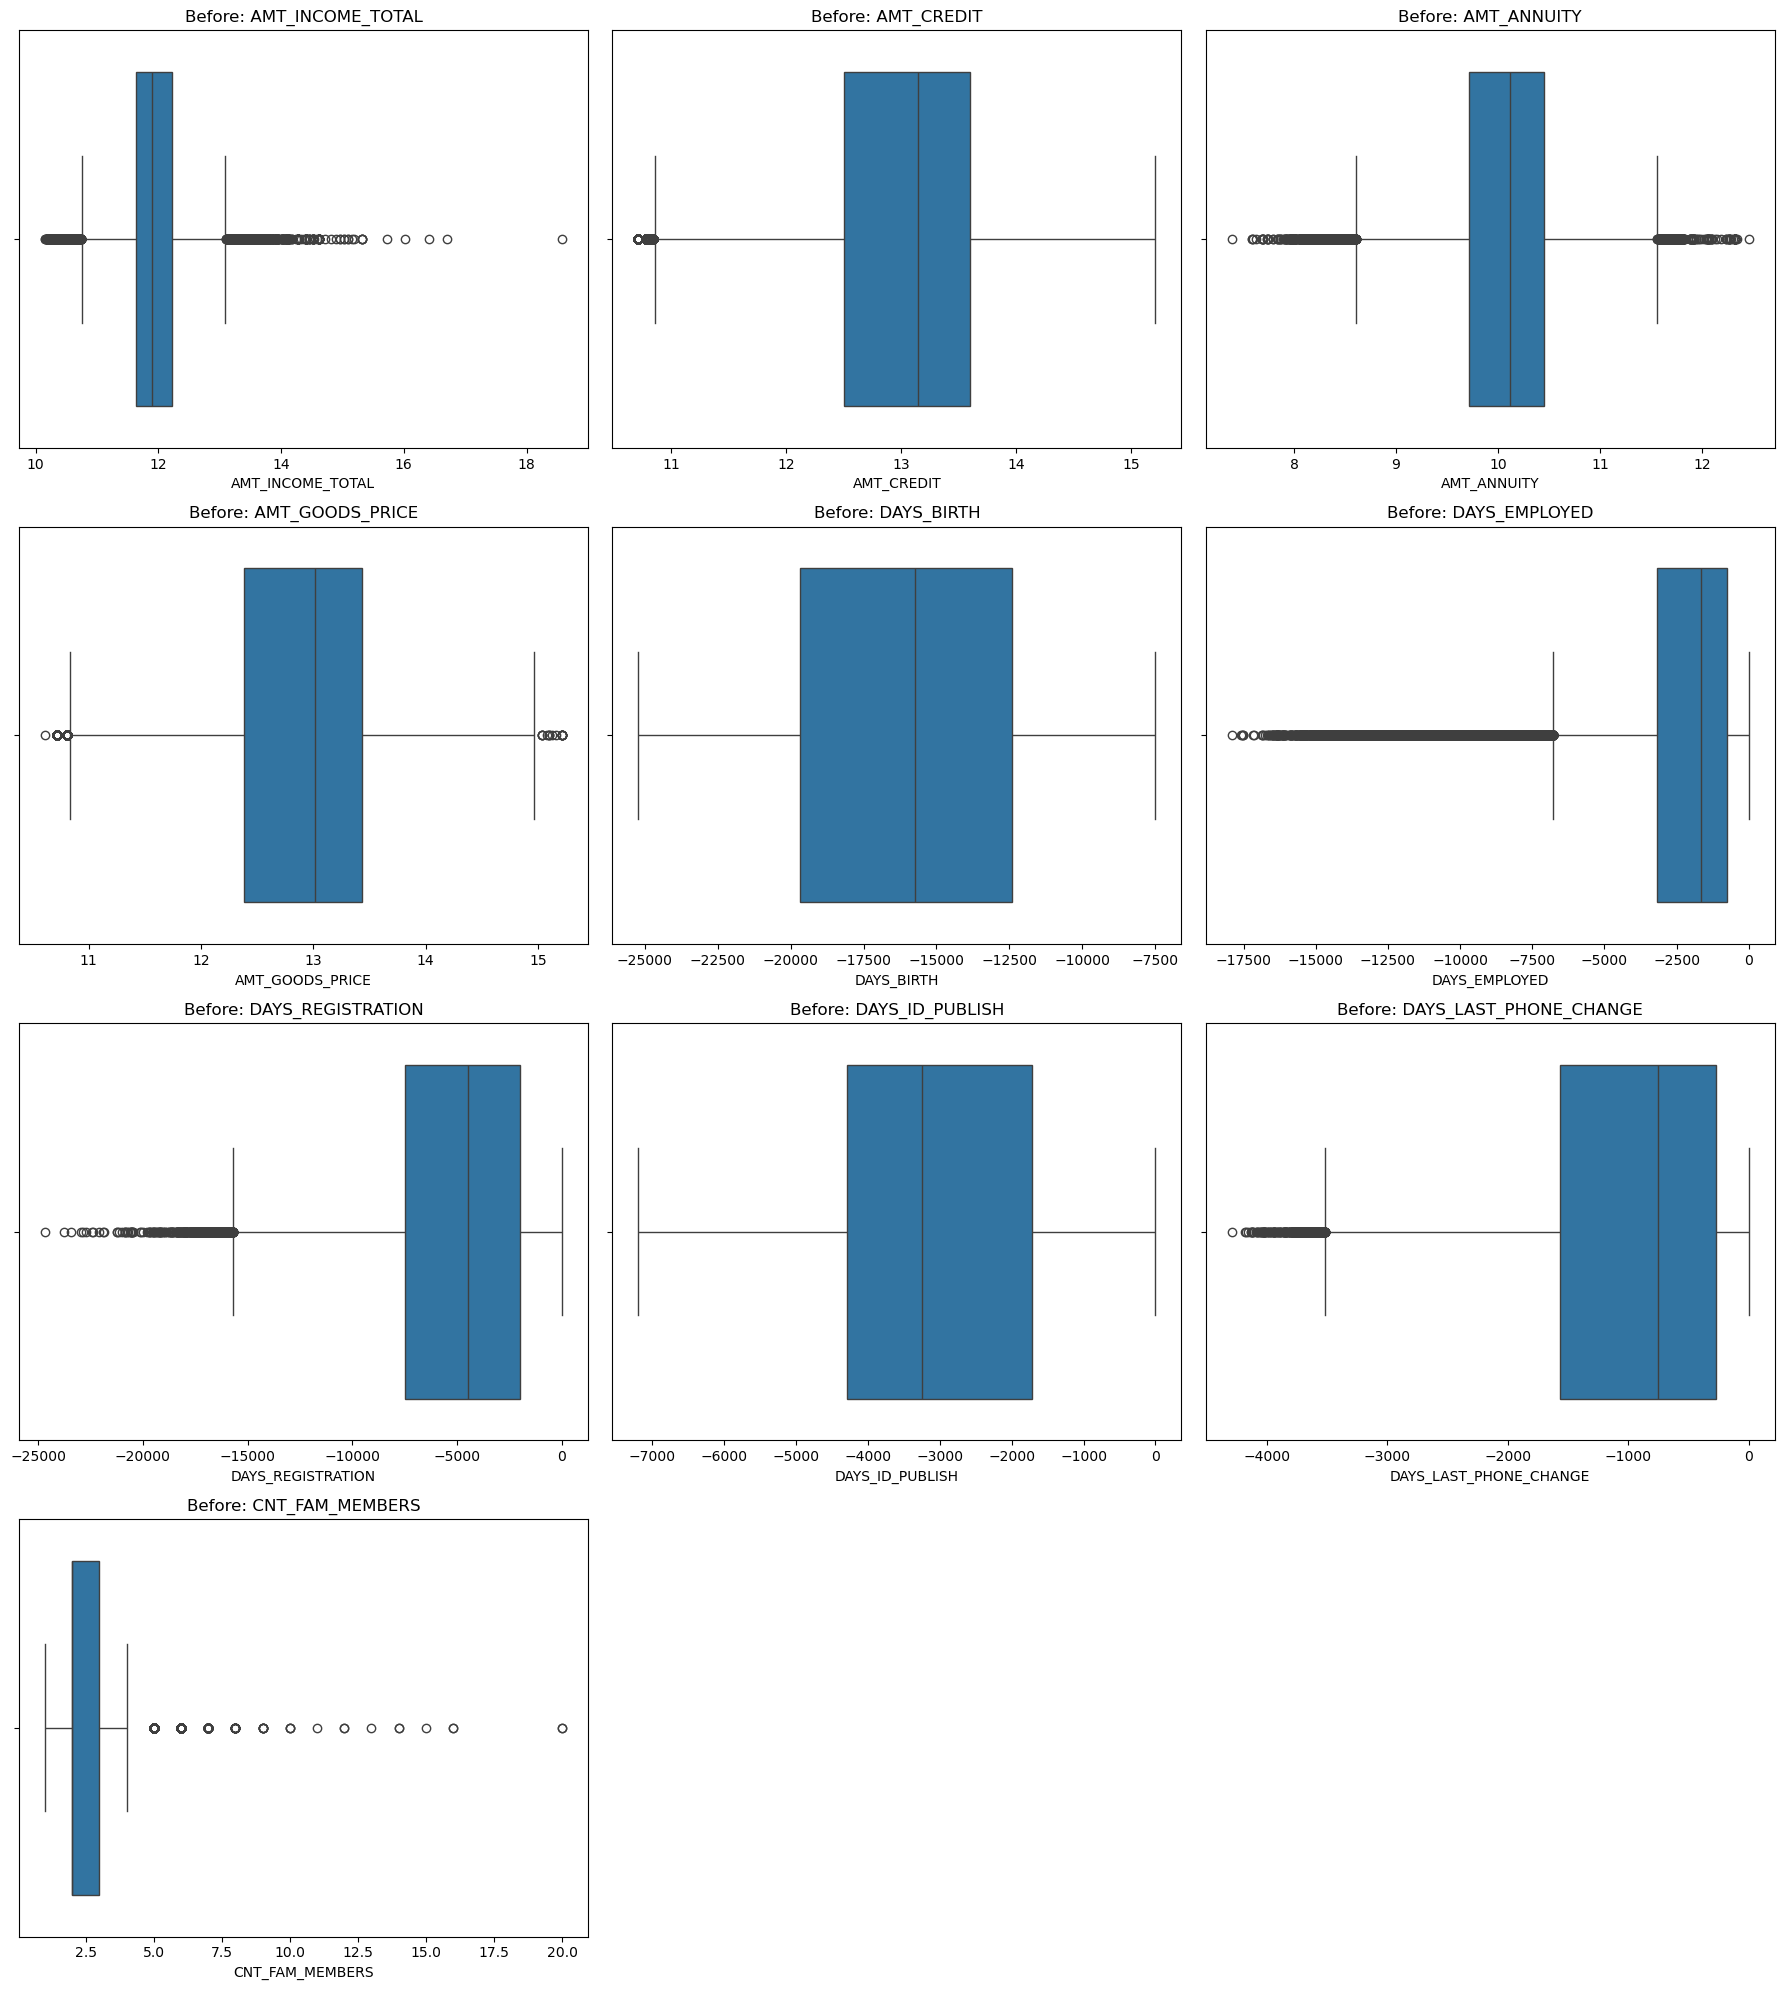


Outlier Summary After Handling:
                  Feature  Outlier_Count_After   Lower_Bound  Upper_Bound
0        AMT_INCOME_TOTAL                    0     10.749043    13.100174
1              AMT_CREDIT                    0     10.860768    15.248535
2             AMT_ANNUITY                    0      8.604291    11.559861
3         AMT_GOODS_PRICE                    0     10.811651    14.999592
4              DAYS_BIRTH                    0 -30585.500000 -1509.500000
5           DAYS_EMPLOYED                    0  -6787.000000  2845.000000
6       DAYS_REGISTRATION                    0 -15683.750000  6194.250000
7         DAYS_ID_PUBLISH                    0  -8167.500000  2148.500000
8  DAYS_LAST_PHONE_CHANGE                    0  -3514.000000  1670.000000
9         CNT_FAM_MEMBERS                    0      0.500000     4.500000


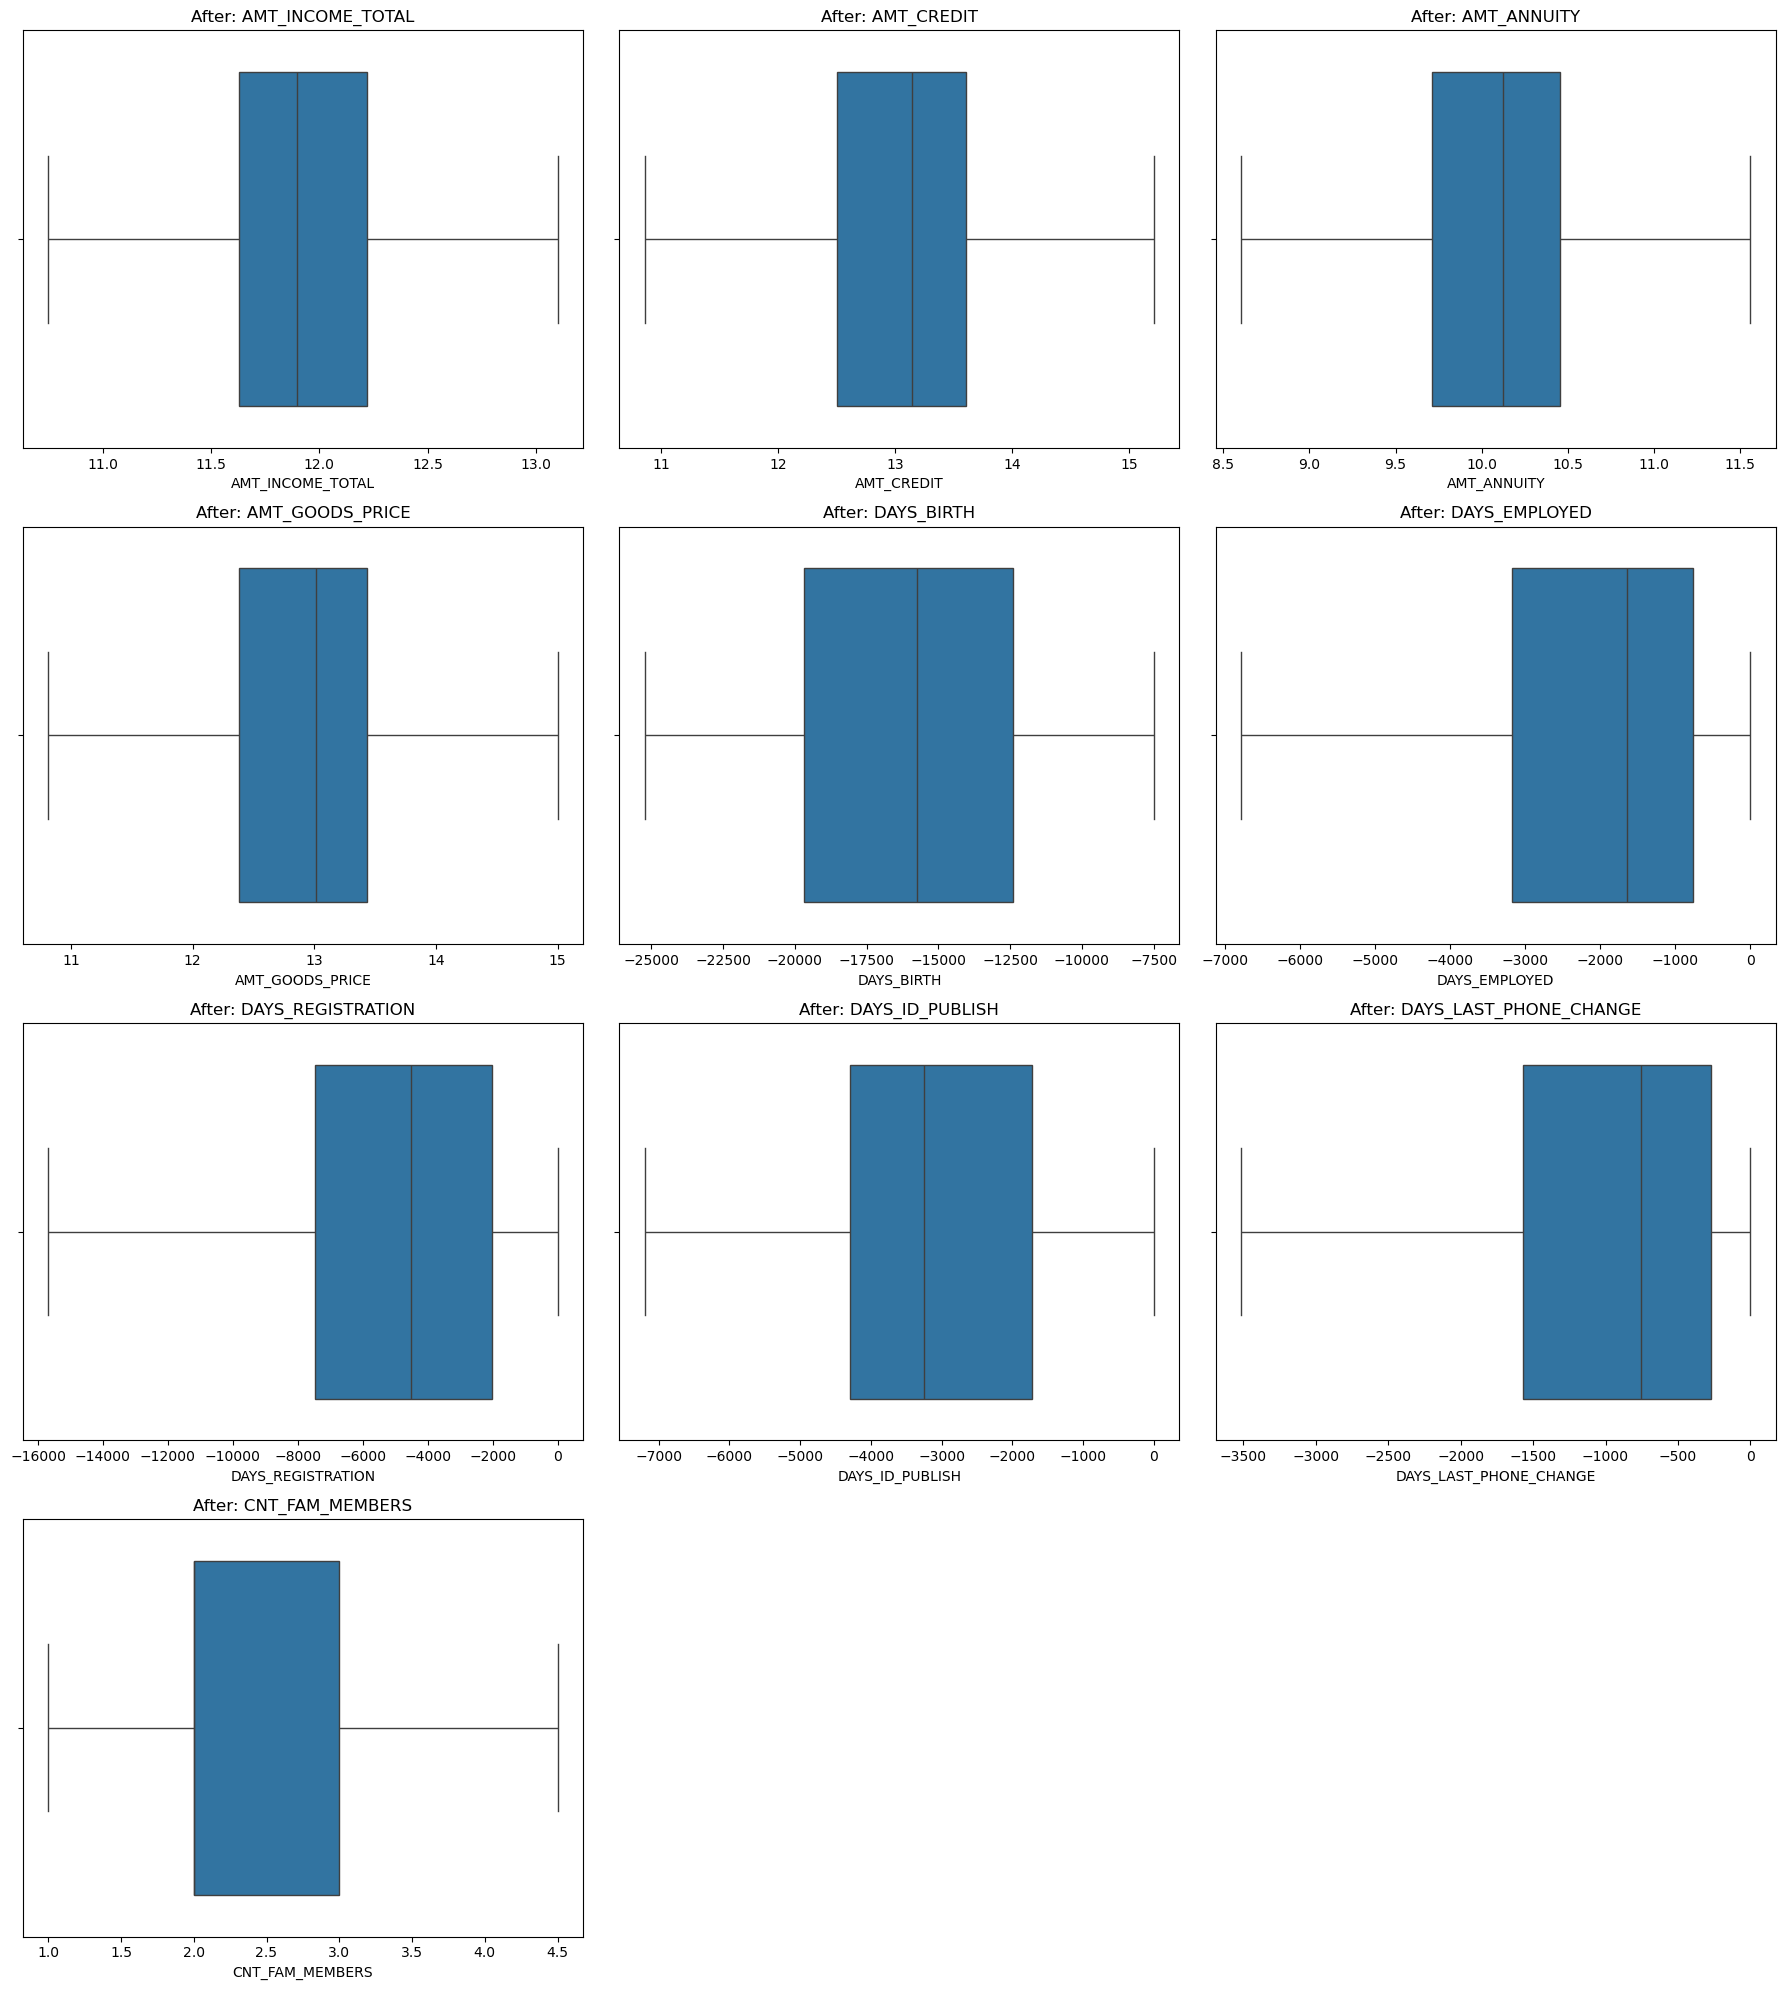

In [26]:
# Create a copy

df_out = df.copy()

#  Replace anomaly value

if 'DAYS_EMPLOYED' in df_out.columns:
    df_out['DAYS_EMPLOYED'] = df_out['DAYS_EMPLOYED'].replace(365243, np.nan)

#  Define columns

monetary_cols = [
    'AMT_INCOME_TOTAL',
    'AMT_CREDIT',
    'AMT_ANNUITY',
    'AMT_GOODS_PRICE'
]
monetary_cols = [col for col in monetary_cols if col in df_out.columns]

treat_outlier_cols = [
    'AMT_INCOME_TOTAL',
    'AMT_CREDIT',
    'AMT_ANNUITY',
    'AMT_GOODS_PRICE',
    'DAYS_BIRTH',
    'DAYS_EMPLOYED',
    'DAYS_REGISTRATION',
    'DAYS_ID_PUBLISH',
    'DAYS_LAST_PHONE_CHANGE',
    'OWN_CAR_AGE',
    'CNT_FAM_MEMBERS'
]
treat_outlier_cols = [col for col in treat_outlier_cols if col in df_out.columns]

#  Log transform monetary columns

for col in monetary_cols:
    df_out[col] = np.log1p(df_out[col])

#  Function for IQR capping

def cap_outliers_iqr(data, column):
    Q1 = data[column].quantile(0.25)
    Q3 = data[column].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    data[column] = data[column].clip(lower=lower_bound, upper=upper_bound)

    return lower_bound, upper_bound

#  Summary before handling

before_summary = []

for col in treat_outlier_cols:
    temp = df_out[col].dropna()

    Q1 = temp.quantile(0.25)
    Q3 = temp.quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outlier_count = ((temp < lower_bound) | (temp > upper_bound)).sum()

    before_summary.append({
        'Feature': col,
        'Outlier_Count_Before': outlier_count,
        'Lower_Bound': lower_bound,
        'Upper_Bound': upper_bound
    })

before_df = pd.DataFrame(before_summary).sort_values(by='Outlier_Count_Before', ascending=False)
print("Outlier Summary Before Handling:")
print(before_df)

#  Boxplot before handling 

plot_cols = treat_outlier_cols
n_cols = 3
n_rows = int(np.ceil(len(plot_cols) / n_cols))

plt.figure(figsize=(18, 5 * n_rows))
for i, col in enumerate(plot_cols, 1):
    plt.subplot(n_rows, n_cols, i)
    sns.boxplot(x=df_out[col])
    plt.title(f'Before: {col}')
plt.tight_layout()
plt.show()

#  Apply IQR capping

for col in treat_outlier_cols:
    cap_outliers_iqr(df_out, col)

# Summary after handling

after_summary = []

for col in treat_outlier_cols:
    temp = df_out[col].dropna()

    Q1 = temp.quantile(0.25)
    Q3 = temp.quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outlier_count = ((temp < lower_bound) | (temp > upper_bound)).sum()

    after_summary.append({
        'Feature': col,
        'Outlier_Count_After': outlier_count,
        'Lower_Bound': lower_bound,
        'Upper_Bound': upper_bound
    })

after_df = pd.DataFrame(after_summary).sort_values(by='Outlier_Count_After', ascending=False)
print("\nOutlier Summary After Handling:")
print(after_df)

# Boxplot after handling - all columns

plt.figure(figsize=(18, 5 * n_rows))
for i, col in enumerate(plot_cols, 1):
    plt.subplot(n_rows, n_cols, i)
    sns.boxplot(x=df_out[col])
    plt.title(f'After: {col}')
plt.tight_layout()
plt.show()

### DATA TYPE OPTIMIZATION

In [27]:
for col in df.select_dtypes(include='float64'):
    df[col] = df[col].astype('float32')

### SAMPLING

In [28]:
df = df.sample(n=50000, random_state=42)

In [29]:
df

,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,AMT_GOODS_PRICE,NAME_TYPE_SUITE,NAME_INCOME_TYPE,NAME_EDUCATION_TYPE,NAME_FAMILY_STATUS,NAME_HOUSING_TYPE,REGION_POPULATION_RELATIVE,DAYS_BIRTH,DAYS_EMPLOYED,DAYS_REGISTRATION,DAYS_ID_PUBLISH,FLAG_MOBIL,FLAG_EMP_PHONE,FLAG_WORK_PHONE,FLAG_CONT_MOBILE,FLAG_PHONE,FLAG_EMAIL,OCCUPATION_TYPE,CNT_FAM_MEMBERS,REGION_RATING_CLIENT,REGION_RATING_CLIENT_W_CITY,WEEKDAY_APPR_PROCESS_START,HOUR_APPR_PROCESS_START,REG_REGION_NOT_LIVE_REGION,REG_REGION_NOT_WORK_REGION,LIVE_REGION_NOT_WORK_REGION,REG_CITY_NOT_LIVE_CITY,REG_CITY_NOT_WORK_CITY,LIVE_CITY_NOT_WORK_CITY,ORGANIZATION_TYPE,EXT_SOURCE_2,EXT_SOURCE_3,OBS_30_CNT_SOCIAL_CIRCLE,DEF_30_CNT_SOCIAL_CIRCLE,OBS_60_CNT_SOCIAL_CIRCLE,DEF_60_CNT_SOCIAL_CIRCLE,DAYS_LAST_PHONE_CHANGE,FLAG_DOCUMENT_2,FLAG_DOCUMENT_3,FLAG_DOCUMENT_4,FLAG_DOCUMENT_5,FLAG_DOCUMENT_6,FLAG_DOCUMENT_7,FLAG_DOCUMENT_8,FLAG_DOCUMENT_9,FLAG_DOCUMENT_10,FLAG_DOCUMENT_11,FLAG_DOCUMENT_12,FLAG_DOCUMENT_13,FLAG_DOCUMENT_14,FLAG_DOCUMENT_15,FLAG_DOCUMENT_16,FLAG_DOCUMENT_17,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR,AGE_YEARS
245895,0,Cash loans,M,Y,N,2,207000.0,465457.5,52641.0,418500.0,Unaccompanied,Commercial associate,Secondary / secondary special,Married,House / apartment,0.009630,-13297,-762,-637.0,-4307,1,1,0,1,0,0,Sales staff,4.0,2,2,THURSDAY,11,0,0,0,0,1,1,Business Entity Type 3,0.604894,0.000527,0.0,0.0,0.0,0.0,-2.0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.0,0.0,0.0,1.0,0.0,1.0,36.430138
98194,0,Cash loans,F,Y,Y,0,247500.0,1281712.5,48946.5,1179000.0,Unaccompanied,Commercial associate,Higher education,Single / not married,House / apartment,0.006852,-14778,-1141,-1610.0,-4546,1,1,0,1,0,1,Managers,1.0,3,3,THURSDAY,10,0,0,0,0,0,0,Business Entity Type 3,0.425351,0.712155,2.0,0.0,2.0,0.0,-1071.0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.0,0.0,0.0,1.0,0.0,3.0,40.487671
36463,0,Cash loans,F,Y,N,0,202500.0,495000.0,39109.5,495000.0,Unaccompanied,Working,Secondary / secondary special,Married,House / apartment,0.035792,-17907,-639,-2507.0,-1461,1,1,1,1,0,0,Sales staff,2.0,2,2,TUESDAY,16,0,0,0,0,0,0,Self-employed,0.531760,0.207964,5.0,0.0,5.0,0.0,-1435.0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.0,0.0,0.0,1.0,0.0,3.0,49.060272
249923,0,Cash loans,F,N,Y,0,247500.0,254700.0,24939.0,225000.0,Unaccompanied,State servant,Secondary / secondary special,Widow,House / apartment,0.046220,-19626,-6982,-11167.0,-3158,1,1,0,1,0,0,High skill tech staff,1.0,1,1,FRIDAY,14,0,0,0,0,0,0,Business Entity Type 3,0.693521,0.614414,0.0,0.0,0.0,0.0,-2000.0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0,53.769863
158389,0,Cash loans,M,N,Y,0,112500.0,308133.0,15862.5,234000.0,Unaccompanied,Working,Secondary / secondary special,Single / not married,House / apartment,0.018850,-20327,-1105,-7299.0,-494,1,1,0,1,0,0,Laborers,1.0,2,2,WEDNESDAY,11,0,0,0,0,0,0,Business Entity Type 3,0.560690,0.636376,0.0,0.0,0.0,0.0,-173.0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.0,0.0,0.0,0.0,0.0,4.0,55.690411
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
252818,0,Cash loans,F,N,N,0,76500.0,450000.0,30442.5,450000.0,Unaccompanied,Working,Secondary / secondary special,Married,With parents,0.022625,-10105,-692,-3861.0,-2365,1,1,1,1,0,0,Core staff,2.0,2,2,SATURDAY,19,0,0,0,0,0,0,Self-employed,0.556096,0.535276,0.0,0.0,0.0,0.0,-687.0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.0,0.0,0.0,0.0,0.0,1.0,27.684931
185810,0,Cash loans,M,N,N,0,90000.0,180000.0,14350.5,180000.0,Unaccompanied,Commercial associate,Secondary / second

In [30]:
df['TARGET'].value_counts()

TARGET
0    45977
1     4023
Name: count, dtype: int64

### LABEL ENCODING

In [31]:
cat_cols = df.select_dtypes(include=['object']).columns

num_cols = df.select_dtypes(include=['int64','float32']).columns

print("Categorical Columns:", len(cat_cols))
print("Numerical Columns:", len(num_cols))

Categorical Columns: 12
Numerical Columns: 61


In [32]:
cat_cols

Index(['NAME_CONTRACT_TYPE', 'CODE_GENDER', 'FLAG_OWN_CAR', 'FLAG_OWN_REALTY',
       'NAME_TYPE_SUITE', 'NAME_INCOME_TYPE', 'NAME_EDUCATION_TYPE',
       'NAME_FAMILY_STATUS', 'NAME_HOUSING_TYPE', 'OCCUPATION_TYPE',
       'WEEKDAY_APPR_PROCESS_START', 'ORGANIZATION_TYPE'],
      dtype='object')

In [33]:

le1 = LabelEncoder()
le2 = LabelEncoder()
le3 = LabelEncoder()
le4 = LabelEncoder()
le5 = LabelEncoder()
le6 = LabelEncoder()
le7 = LabelEncoder()
le8 = LabelEncoder()
le9 = LabelEncoder()
le10 = LabelEncoder()
le11 = LabelEncoder()
le12 = LabelEncoder()

df['NAME_CONTRACT_TYPE'] = le1.fit_transform(df['NAME_CONTRACT_TYPE'])
df['CODE_GENDER'] = le2.fit_transform(df['CODE_GENDER'])
df['FLAG_OWN_CAR'] = le3.fit_transform(df['FLAG_OWN_CAR'])
df['FLAG_OWN_REALTY'] = le4.fit_transform(df['FLAG_OWN_REALTY'])
df['NAME_TYPE_SUITE'] = le5.fit_transform(df['NAME_TYPE_SUITE'])
df['NAME_INCOME_TYPE'] = le6.fit_transform(df['NAME_INCOME_TYPE'])
df['NAME_EDUCATION_TYPE'] = le7.fit_transform(df['NAME_EDUCATION_TYPE'])
df['NAME_FAMILY_STATUS'] = le8.fit_transform(df['NAME_FAMILY_STATUS'])
df['NAME_HOUSING_TYPE'] = le9.fit_transform(df['NAME_HOUSING_TYPE'])
df['OCCUPATION_TYPE'] = le10.fit_transform(df['OCCUPATION_TYPE'])
df['WEEKDAY_APPR_PROCESS_START'] = le11.fit_transform(df['WEEKDAY_APPR_PROCESS_START'])
df['ORGANIZATION_TYPE'] = le12.fit_transform(df['ORGANIZATION_TYPE'])

In [34]:
for col in df.select_dtypes(include='int64'):
    df[col] = df[col].astype('int32')

### CORRELATION ANALYSIS

In [35]:
df.corr()

,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,AMT_GOODS_PRICE,NAME_TYPE_SUITE,NAME_INCOME_TYPE,NAME_EDUCATION_TYPE,NAME_FAMILY_STATUS,NAME_HOUSING_TYPE,REGION_POPULATION_RELATIVE,DAYS_BIRTH,DAYS_EMPLOYED,DAYS_REGISTRATION,DAYS_ID_PUBLISH,FLAG_MOBIL,FLAG_EMP_PHONE,FLAG_WORK_PHONE,FLAG_CONT_MOBILE,FLAG_PHONE,FLAG_EMAIL,OCCUPATION_TYPE,CNT_FAM_MEMBERS,REGION_RATING_CLIENT,REGION_RATING_CLIENT_W_CITY,WEEKDAY_APPR_PROCESS_START,HOUR_APPR_PROCESS_START,REG_REGION_NOT_LIVE_REGION,REG_REGION_NOT_WORK_REGION,LIVE_REGION_NOT_WORK_REGION,REG_CITY_NOT_LIVE_CITY,REG_CITY_NOT_WORK_CITY,LIVE_CITY_NOT_WORK_CITY,ORGANIZATION_TYPE,EXT_SOURCE_2,EXT_SOURCE_3,OBS_30_CNT_SOCIAL_CIRCLE,DEF_30_CNT_SOCIAL_CIRCLE,OBS_60_CNT_SOCIAL_CIRCLE,DEF_60_CNT_SOCIAL_CIRCLE,DAYS_LAST_PHONE_CHANGE,FLAG_DOCUMENT_2,FLAG_DOCUMENT_3,FLAG_DOCUMENT_4,FLAG_DOCUMENT_5,FLAG_DOCUMENT_6,FLAG_DOCUMENT_7,FLAG_DOCUMENT_8,FLAG_DOCUMENT_9,FLAG_DOCUMENT_10,FLAG_DOCUMENT_11,FLAG_DOCUMENT_12,FLAG_DOCUMENT_13,FLAG_DOCUMENT_14,FLAG_DOCUMENT_15,FLAG_DOCUMENT_16,FLAG_DOCUMENT_17,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR,AGE_YEARS
TARGET,1.000000,-0.027271,0.054831,-0.017461,-0.004572,0.018300,0.010135,-0.026247,-0.013516,-0.036141,0.016283,0.051302,0.058314,-0.002555,0.041877,-0.037753,0.079109,-0.044225,0.042465,0.047562,NaN,0.045345,0.025436,0.001216,-0.027696,-0.010732,-0.013363,0.008046,0.061030,0.059882,0.007254,-0.030576,0.006573,0.011479,0.005310,0.044689,0.051847,0.029928,-0.029653,-0.168265,-0.149445,0.008782,0.028741,0.008773,0.025783,0.064984,-0.002646,0.043427,-0.003241,-0.000717,-0.026043,0.003472,-0.011509,-0.005532,-0.002291,-0.002349,-0.001323,-0.012806,-0.009272,-0.010996,-0.008452,-0.005614,-0.006522,-0.005049,0.007766,0.013096,-4.163588e-04,-0.001961,0.000661,-0.015105,-0.008612,0.012584,-0.079109
NAME_CONTRACT_TYPE,-0.027271,1.000000,-0.007641,0.001050,0.067573,0.034920,-0.003434,-0.221444,-0.241178,-0.186260,0.011240,0.004289,-0.071231,0.011392,0.031107,0.029281,0.087335,-0.051773,0.017396,0.055809,NaN,0.052312,-0.035110,-0.096145,-0.016117,-0.003778,-0.027104,0.013652,-0.023970,-0.025085,-0.010818,0.039744,0.017190,0.011919,0.004233,0.017113,0.010118,-0.002778,-0.040993,0.019858,-0.007533,-0.029615,-0.017973,-0.029778,-0.014776,0.060592,-0.002862,-0.475273,0.009075,0.033219,-0.096654,0.034236,-0.082272,-0.008967,0.024208,0.025736,-0.001431,-0.005336,0.005532,-0.010039,-0.022591,-0.006072,-0.009935,-0.008469,-0.007840,0.057397,1.815751e-03,-0.009398,-0.021533,-0.014685,-0.024763,-0.056235,-0.087335
CODE_GENDER,0.054831,-0.007641,1.000000,0.337534,-0.046273,0.043896,0.030207,0.017157,0.071027,0.018353,0.036334,0.060270,0.009084,-0.103197,0.059948,0.014196,0.151600,-0.156721,0.076132,0.001110,NaN,0.158071,0.042916,-0.008157,-0.008046,0.023254,-0.133136,0.076491,-0.014021,-0.012201,-0.002105,0.013810,0.026144,0.105856,0.107872,0.050858,0.135287,0.129644,-0.159811,-0.015658,-0.019946,-0.015455,-0.016838,-0.014773,-0.013025,0.030704,-0.001682,-0.091752,-0.000132,0.004315,-0.100907,0.003725,0.254616,-0.006854,-0.000093,0.011763,0.006244,0.041245,0.004807,0.022312,0.001889,0.013133,0.031807,0.006603,0.008331,0.025053,5.019653e-03,0.000202,-0.004688,0.004261,-0.016160,-0.025729,-0.151600
FLAG_OWN_CAR,-0.017461,0.001050,0.337534,1.000000,0.001757,0.096821,0.032612,0.108963,0.137529,0.113592,0.003306,0.032571,-0.091900,-0.131479,-0.001147,0.039974,0.128616,-0.151848,0.084002,0.008008,NaN,0.152115,0.015026,-0.003490,-0.000967,0.030013,-0.118526,0.144730,-0.018918,-0.018570,-0.000671,0.017576,0.004473,0.043006,0.049909,0.008473,0.072293,0.083269,-0.113484,0.053977,-0.015948,-0.002484,-0.023666,-0.002365,-0.019566,-0.036390,-0.001653,-0.071060,0.003768,-0.009882,-0.101877,0.007630,0.227518,-0.011394,0.005395,0.003266,0.00626

### CORRELATION HEATMAP

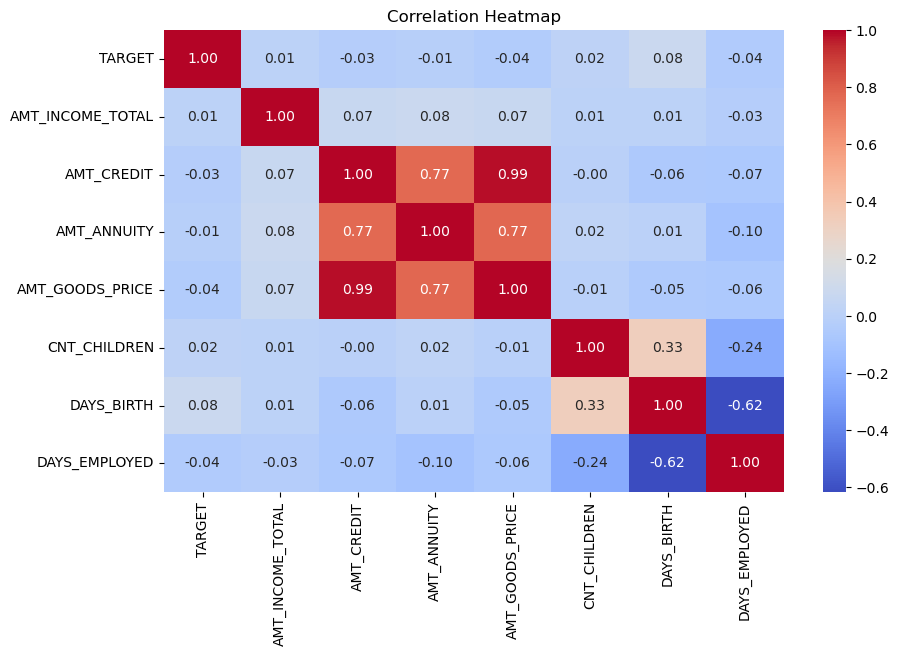

In [36]:
corr_cols = ['TARGET', 'AMT_INCOME_TOTAL', 'AMT_CREDIT', 'AMT_ANNUITY',
             'AMT_GOODS_PRICE', 'CNT_CHILDREN', 'DAYS_BIRTH', 'DAYS_EMPLOYED']
plt.figure(figsize=(10,6))
sns.heatmap(df[corr_cols].corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title("Correlation Heatmap")
plt.show()

## FEATURE ENGINEERING

### FEATURE SELECTION

In [37]:
corr_matrix = df.corr().abs()
upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))

high_corr_cols = [col for col in upper.columns if any(upper[col] > 0.9)]
df = df.drop(columns=high_corr_cols)

x= df.drop(columns=['TARGET'])

y = df['TARGET']
from sklearn.feature_selection import SelectKBest, f_classif  # statistical test

selector = SelectKBest(score_func=f_classif, k=50)
X_new = selector.fit_transform(x, y)

X_new.shape

selected_cols = x.columns[selector.get_support()]

## DATA SPLITTING

In [38]:
x= df.drop(columns=['TARGET'])

y = df['TARGET']

### TRAIN TEST SPLIT 

In [39]:
xtrain,xtest,ytrain,ytest=train_test_split(x,y,test_size=0.2,random_state=42)

## FEATURE SCALING

In [40]:
scaler = StandardScaler()

x_train = scaler.fit_transform(xtrain)
x_test = scaler.transform(xtest)

## MODEL BUILDING & TRAINING

### LOGISTIC REGRESSION

In [41]:
model=LogisticRegression()
model.fit(x_train,ytrain)

LogisticRegression()

In [42]:
test_pred=model.predict(x_test)
train_pred=model.predict(x_train)

In [43]:
accuracy = accuracy_score(ytest, test_pred)
accuracy

0.9205

In [44]:
accuracy_score(ytrain, train_pred)

0.9195

In [45]:
train_score = model.score(x_train, ytrain)
test_score  = model.score(x_test, ytest)
print("train_score",train_score)
print("test_score",test_score)

train_score 0.9195
test_score 0.9205


### DECISION TREE CLASSIFIER

In [46]:
dt=DecisionTreeClassifier()
dt.fit(xtrain,ytrain)

DecisionTreeClassifier()

In [47]:
test_pred1=dt.predict(xtest)
train_pred1=dt.predict(xtrain)

In [48]:
accuracy_score(ytest, test_pred1)

0.8493

In [49]:
accuracy_score(ytrain, train_pred1)

1.0

In [50]:
train_score = dt.score(xtrain, ytrain)
test_score  = dt.score(xtest, ytest)
print("train_score",train_score)
print("test_score",test_score)

train_score 1.0
test_score 0.8493


### RANDOM FOREST CLASSIFIER

In [51]:
Rc=RandomForestClassifier(n_estimators=100,random_state=42,max_depth=8)
Rc.fit(xtrain,ytrain)

RandomForestClassifier(max_depth=8, random_state=42)

In [52]:
test_pred2=Rc.predict(xtest)
train_pred2=Rc.predict(xtrain)

In [53]:
accuracy_score(ytest, test_pred2)

0.9206

In [54]:
accuracy_score(ytrain, train_pred2)

0.919275

In [55]:
train_score = Rc.score(xtrain, ytrain)
test_score  = Rc.score(xtest, ytest)
print("train_score",train_score)
print("test_score",test_score)

train_score 0.919275
test_score 0.9206


### ADA BOOST CLASSIFIER

In [56]:
ad=AdaBoostClassifier(n_estimators=100)
ad.fit(xtrain,ytrain)

AdaBoostClassifier(n_estimators=100)

In [57]:
test_pred3=ad.predict(xtest)
train_pred3=ad.predict(xtrain)

In [58]:
accuracy_score(ytest, test_pred3)

0.9209

In [59]:
accuracy_score(ytrain, train_pred3)

0.9195

In [60]:
train_score = ad.score(xtrain, ytrain)
test_score  = ad.score(xtest, ytest)
print("train_score",train_score)
print("test_score",test_score)

train_score 0.9195
test_score 0.9209


### GRADIENTBOOST CLASSIFIER

In [61]:
Gb=GradientBoostingClassifier()
Gb.fit(xtrain,ytrain)

GradientBoostingClassifier()

In [62]:
test_pred4=Gb.predict(xtest)
train_pred4=Gb.predict(xtrain)

In [63]:
accuracy_score(ytest, test_pred4)

0.9207

In [64]:
accuracy_score(ytrain, train_pred4)

0.920675

In [65]:
train_score = Gb.score(xtrain, ytrain)
test_score  = Gb.score(xtest, ytest)
print("train_score",train_score)
print("test_score",test_score)

train_score 0.920675
test_score 0.9207


### SUPPORT VECTOR MACHINE

In [66]:
sv=SVC()
sv.fit(x_train,ytrain)

SVC()

In [67]:
test_pred5=sv.predict(x_test)
train_pred5=sv.predict(x_train)

In [68]:
accuracy_score(ytest, test_pred5)

0.9206

In [69]:
accuracy_score(ytrain, train_pred5)

0.919425

In [70]:
train_score = sv.score(xtrain, ytrain)
test_score  = sv.score(xtest, ytest)
print("train_score",train_score)
print("test_score",test_score)

train_score 0.919275
test_score 0.9206


### K NEAREST NEIGHBORS

In [71]:
kn=KNeighborsClassifier()
kn.fit(x_train,ytrain)

KNeighborsClassifier()

In [72]:
test_pred6=kn.predict(x_test)
train_pred6=kn.predict(x_train)

In [73]:
accuracy_score(ytest, test_pred6)

0.9175

In [74]:
accuracy_score(ytrain, train_pred6)

0.92315

In [75]:
train_score = kn.score(xtrain, ytrain)
test_score  = kn.score(xtest, ytest)
print("train_score",train_score)
print("test_score",test_score)

train_score 0.919275
test_score 0.9206


## XGBOOSTING

In [76]:
xg=XGBClassifier(use_label_encoder=False, eval_metric='logloss')
xg.fit(xtrain,ytrain)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=None, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=None, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=None, n_jobs=None,
              num_parallel_tree=None, ...)

In [77]:
test_pred7=xg.predict(xtest)
train_pred7=xg.predict(xtrain)

In [78]:
accuracy_score(ytest, test_pred7)

0.9173

In [79]:
accuracy_score(ytrain, train_pred7)

0.94545

In [80]:
train_score = xg.score(xtrain, ytrain)
test_score  = xg.score(xtest, ytest)
print("train_score",train_score)
print("test_score",test_score)

train_score 0.94545
test_score 0.9173


## ACCURACY COMPARISON 

In [81]:

models = {
    "Logistic Regression": LogisticRegression(),
    "Decision Tree": DecisionTreeClassifier(),
    "Random Forest": RandomForestClassifier(n_estimators=100,random_state=42),
    "SVM": SVC(),
    "KNN": KNeighborsClassifier(),
    "AdaBoost": AdaBoostClassifier(n_estimators=100),
    "Gradient Boost": GradientBoostingClassifier(),
    "XGBoost": XGBClassifier(use_label_encoder=False, eval_metric='logloss')
}

for name, model in models.items():
    
    if name in ["Logistic Regression","Decision Tree","KNN"]:
        model.fit(x_train, ytrain)
        pred = model.predict(x_test)
    else:
        model.fit(xtrain, ytrain)
        pred = model.predict(xtest)

    acc = accuracy_score(ytest, pred)
    print(name, "Accuracy:", acc)

Logistic Regression Accuracy: 0.9205
Decision Tree Accuracy: 0.8496
Random Forest Accuracy: 0.9208
SVM Accuracy: 0.9206
KNN Accuracy: 0.9175
AdaBoost Accuracy: 0.9209
Gradient Boost Accuracy: 0.9207
XGBoost Accuracy: 0.9173


## HYPER PARAMETER TUNING

### LR

In [82]:
lr_params = {
    'C':[1,5,10]}

lr_grid = GridSearchCV(LogisticRegression(max_iter=500),
                       lr_params,
                       cv=5,
                       scoring='accuracy')

lr_grid.fit(x_train,ytrain)
best_lr = lr_grid.best_estimator_
lr_test_pred=best_lr.predict(x_test)
lr_train_pred=best_lr.predict(x_train)

print("Best Params:", lr_grid.best_params_)
print("Test Accuracy:" ,accuracy_score(ytest,lr_test_pred))
print("Train Accuracy:" ,accuracy_score(ytrain,lr_train_pred))

Best Params: {'C': 1}
Test Accuracy: 0.9205
Train Accuracy: 0.9195


### DT

In [83]:
dt_params = {
    'max_depth':[3,5,10,None],
    'min_samples_split':[2,5,10],
    'criterion':['gini','entropy']
}

dt_grid = GridSearchCV(DecisionTreeClassifier(),
                       dt_params,
                       cv=5)

dt_grid.fit(xtrain,ytrain)
best_dt = dt_grid.best_estimator_
dt_test_pred=best_dt.predict(xtest)
dt_train_pred=best_dt.predict(xtrain)

print('best params: ',dt_grid.best_params_)
print('Test Accuracy Score: ',accuracy_score(ytest,dt_test_pred))
print('Train Accuracy score: ',accuracy_score(ytrain,dt_train_pred))

best params:  {'criterion': 'gini', 'max_depth': 3, 'min_samples_split': 2}
Test Accuracy Score:  0.9205
Train Accuracy score:  0.919475


### RF

In [84]:
import warnings
warnings.filterwarnings("ignore")

rf_params = {
    'n_estimators':[100,200],
    'max_depth':[5,10,15],
    'min_samples_split':[5,10,20],
    'min_samples_leaf':[2,4,8],
    'max_features':['sqrt','log2']
}

rf_grid = GridSearchCV(RandomForestClassifier(random_state=42),
                       rf_params,
                       cv=5,
                      n_jobs=-1,
                      scoring='f1'
)

rf_grid.fit(xtrain,ytrain)

best_rf = rf_grid.best_estimator_
rf_test_pred=best_rf.predict(xtest)
rf_train_pred=best_rf.predict(xtrain)
print("Best Params:", rf_grid.best_params_)
print("Test Accuracy:" ,accuracy_score(ytest,rf_test_pred))
print("Train Accuracy: ",accuracy_score(ytrain,rf_train_pred))

Best Params: {'max_depth': 15, 'max_features': 'sqrt', 'min_samples_leaf': 2, 'min_samples_split': 10, 'n_estimators': 100}
Test Accuracy: 0.9206
Train Accuracy:  0.922025


### KNN

In [85]:
knn_params = {
    'n_neighbors':[3,5,7,9],
    'weights':['uniform','distance']
}

knn_grid = GridSearchCV(KNeighborsClassifier(),
                        knn_params,
                        cv=5)

knn_grid.fit(x_train,ytrain)
best_knn = knn_grid.best_estimator_
knn_test_pred = best_knn.predict(x_test)
knn_train_pred=best_knn.predict(x_train)
print("Best Params:",knn_grid.best_params_)
print("Test Accuracy:",accuracy_score(ytest,knn_test_pred))
print("Train Accuracy:",accuracy_score(ytrain,knn_train_pred))

Best Params: {'n_neighbors': 9, 'weights': 'uniform'}
Test Accuracy: 0.9202
Train Accuracy: 0.9197


## AB

In [86]:
ada_params = {
    'n_estimators':[50,100,200],
    'learning_rate':[0.01,0.1,1]
}

ada_grid = GridSearchCV(AdaBoostClassifier(),
                        ada_params,
                        cv=5)

ada_grid.fit(xtrain,ytrain)
best_ada = ada_grid.best_estimator_

ada_test_pred = best_ada.predict(xtest)
ada_train_pred=best_ada.predict(xtrain)

print("Best Params:",ada_grid.best_params_)
print("Test Accuracy:",accuracy_score(ytest,ada_test_pred))
print("Train Accuracy:",accuracy_score(ytrain,ada_train_pred))

Best Params: {'learning_rate': 1, 'n_estimators': 200}
Test Accuracy: 0.9208
Train Accuracy: 0.919475


## GB

In [87]:
import warnings
warnings.filterwarnings("ignore")

In [88]:

gb_params = {
    'n_estimators':[100,200],
    'learning_rate':[0.01,0.1],
    'max_depth':[3,5]
}

gb_grid = GridSearchCV(GradientBoostingClassifier(random_state=42),
                       gb_params,
                       cv=3,
                      n_jobs=1
)

gb_grid.fit(xtrain,ytrain)
best_gb = gb_grid.best_estimator_
gb_test_pred = best_gb.predict(xtest)
gb_train_pred=best_gb.predict(xtrain)

print("Best Params:",gb_grid.best_params_)
print("Test Accuracy:",accuracy_score(ytest,gb_test_pred))
print("Train Accuracy:",accuracy_score(ytrain,gb_train_pred))


Exception ignored in: <function ResourceTracker.__del__ at 0x1050c9bc0>
Traceback (most recent call last):
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 82, in __del__
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 91, in _stop
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 116, in _stop_locked
ChildProcessError: [Errno 10] No child processes
Exception ignored in: <function ResourceTracker.__del__ at 0x110165bc0>
Traceback (most recent call last):
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 82, in __del__
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 91, in _stop
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 116, in _stop_locked
ChildProcessError: [Errno 10] No child processes
Exception ignored in: <function ResourceTracker.__del__ at 0x105065bc0>
Traceback (most recent call last

Best Params: {'learning_rate': 0.01, 'max_depth': 5, 'n_estimators': 200}
Test Accuracy: 0.9205
Train Accuracy: 0.920225


### XGB

In [89]:
xgb_params = {
    'n_estimators':[100,200],
    'learning_rate':[0.01,0.1],
    'max_depth':[3,5,7,9]
    
}

xgb_grid = GridSearchCV(XGBClassifier(eval_metric='logloss'),
                        xgb_params,
                        cv=5,
                       scoring='accuracy',
                        n_jobs=-1)

xgb_grid.fit(xtrain,ytrain)
best_xgb = xgb_grid.best_estimator_

xgb_test_pred = best_xgb.predict(xtest)
xgb_train_pred=best_xgb.predict(xtrain)
print("Best Params:",xgb_grid.best_params_)
print("Test Accuracy:",accuracy_score(ytest,xgb_test_pred))
print("Train Accuracy:",accuracy_score(ytrain,xgb_train_pred))

Best Params: {'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 100}
Test Accuracy: 0.9206
Train Accuracy: 0.9199


### SVM

In [90]:
svm_params = {
    'C':[0.1,1,10],
    'kernel':['linear','rbf']
}

svm_grid = GridSearchCV(SVC(max_iter=500),
                        svm_params,
                        cv=3)

svm_grid.fit(x_train,ytrain)

best_svm = svm_grid.best_estimator_
svm_test_pred = best_svm.predict(x_test)
svm_train_pred=best_svm.predict(x_train)
print("Best Params:",svm_grid.best_params_)
print("Test Accuracy:",accuracy_score(ytest,svm_test_pred))
print("Train Accuracy:",accuracy_score(ytrain,svm_train_pred))

Best Params: {'C': 10, 'kernel': 'rbf'}
Test Accuracy: 0.7458
Train Accuracy: 0.749325


## ACCURACY AFTER HYPERPARAMETER TUNING

In [91]:
model_results = pd.DataFrame({
"Model":[
"Logistic Regression",
"Decision Tree",
"Random Forest",
"SVM",
"KNN",
"AdaBoost",
"Gradient Boost",
"XGBoost"
],

"Test Accuracy":[
accuracy_score(ytest,lr_test_pred),
accuracy_score(ytest,dt_test_pred),
accuracy_score(ytest,rf_test_pred),
accuracy_score(ytest,svm_test_pred),
accuracy_score(ytest,knn_test_pred),
accuracy_score(ytest,ada_test_pred),
accuracy_score(ytest,gb_test_pred),
accuracy_score(ytest,xgb_test_pred)
],
"Train Accuracy":[
accuracy_score(ytrain,lr_train_pred),
accuracy_score(ytrain,dt_train_pred),
accuracy_score(ytrain,rf_train_pred),
accuracy_score(ytrain,svm_train_pred),
accuracy_score(ytrain,knn_train_pred),
accuracy_score(ytrain,ada_train_pred),
accuracy_score(ytrain,gb_train_pred),
accuracy_score(ytrain,xgb_train_pred)
]
})

print(model_results)

                 Model  Test Accuracy  Train Accuracy
0  Logistic Regression         0.9205        0.919500
1        Decision Tree         0.9205        0.919475
2        Random Forest         0.9206        0.922025
3                  SVM         0.7458        0.749325
4                  KNN         0.9202        0.919700
5             AdaBoost         0.9208        0.919475
6       Gradient Boost         0.9205        0.920225
7              XGBoost         0.9206        0.919900


## BEST MODEL 

In [92]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
import pandas as pd

results = []

models = {
    "Logistic Regression": (best_lr, x_train, x_test),
    "Decision Tree": (best_dt, xtrain, xtest),
    "Random Forest": (best_rf, xtrain, xtest),
    "SVM":(best_svm, x_train, x_test),
    "KNN": (best_knn, x_train, x_test),
    "AdaBoost": (best_ada, xtrain, xtest),
    "Gradient Boost": (best_gb, xtrain, xtest),
    "XGBoost": (best_xgb, xtrain, xtest)
}

for name, (model, xtr, xte) in models.items():
    y_train_pred = model.predict(xtr)
    y_test_pred = model.predict(xte)

    if hasattr(model, "predict_proba"):
        y_test_prob = model.predict_proba(xte)[:, 1]
        roc_auc = roc_auc_score(ytest, y_test_prob)
    elif hasattr(model, "decision_function"):
         y_test_prob = model.decision_function(xte)
         roc_auc = roc_auc_score(ytest, y_test_prob)
    
    else:
        roc_auc = None

    results.append({
        "Model": name,
        "Train Accuracy": round(accuracy_score(ytrain, y_train_pred), 4),
        "Test Accuracy": round(accuracy_score(ytest, y_test_pred), 4),
        "Precision": round(precision_score(ytest, y_test_pred, zero_division=0), 4),
        "Recall": round(recall_score(ytest, y_test_pred, zero_division=0), 4),
        "F1 Score": round(f1_score(ytest, y_test_pred, zero_division=0), 4),
        "ROC-AUC": round(roc_auc, 4) if roc_auc is not None else None
    })

results_df = pd.DataFrame(results).sort_values(by="ROC-AUC", ascending=False)
print(results_df)

                 Model  Train Accuracy  Test Accuracy  Precision  Recall  \
7              XGBoost          0.9199         0.9206     0.5000  0.0113   
5             AdaBoost          0.9195         0.9208     0.5417  0.0164   
0  Logistic Regression          0.9195         0.9205     0.4615  0.0076   
6       Gradient Boost          0.9202         0.9205     0.4000  0.0025   
2        Random Forest          0.9220         0.9206     0.0000  0.0000   
1        Decision Tree          0.9195         0.9205     0.4667  0.0088   
4                  KNN          0.9197         0.9202     0.3571  0.0063   
3                  SVM          0.7493         0.7458     0.0904  0.2431   

   F1 Score  ROC-AUC  
7    0.0222   0.7400  
5    0.0318   0.7345  
0    0.0149   0.7320  
6    0.0050   0.7290  
2    0.0000   0.7199  
1    0.0173   0.6743  
4    0.0124   0.6030  
3    0.1318   0.5594  


### BEST MODEL : XGBOOST

In [93]:
# XGBoost was selected as the final model because it achieved the highest ROC-AUC score among 
# all evaluated models, making it the most effective model for distinguishing defaulters from 
# non-defaulters in this imbalanced dataset.

Confusion Matrix:
 [[9197    9]
 [ 785    9]]


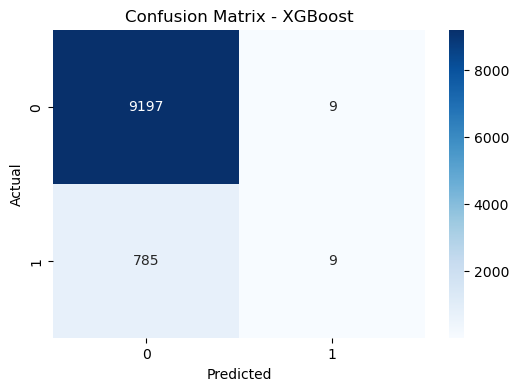

Classification Report:

              precision    recall  f1-score   support

           0       0.92      1.00      0.96      9206
           1       0.50      0.01      0.02       794

    accuracy                           0.92     10000
   macro avg       0.71      0.51      0.49     10000
weighted avg       0.89      0.92      0.88     10000



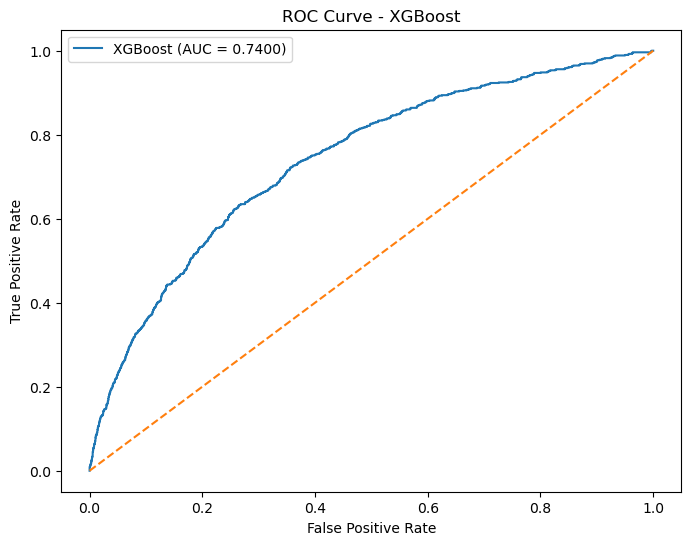

In [94]:
from sklearn.metrics import confusion_matrix, classification_report, roc_curve, auc
import matplotlib.pyplot as plt
import seaborn as sns

# Prediction
y_pred = best_xgb.predict(xtest)
y_prob = best_xgb.predict_proba(xtest)[:, 1]

# Confusion Matrix
cm = confusion_matrix(ytest, y_pred)
print("Confusion Matrix:\n", cm)

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix - XGBoost")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# Classification Report
print("Classification Report:\n")
print(classification_report(ytest, y_pred, zero_division=0))

# ROC Curve
fpr, tpr, thresholds = roc_curve(ytest, y_prob)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8,6))
plt.plot(fpr, tpr, label=f'XGBoost (AUC = {roc_auc:.4f})')
plt.plot([0, 1], [0, 1], linestyle='--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - XGBoost")
plt.legend()
plt.show()

                       Feature  Importance
35                EXT_SOURCE_2    0.132085
36                EXT_SOURCE_3    0.093862
10         NAME_EDUCATION_TYPE    0.051003
9             NAME_INCOME_TYPE    0.042690
32      REG_CITY_NOT_WORK_CITY    0.041850
1                  CODE_GENDER    0.037504
42             FLAG_DOCUMENT_3    0.036143
14                  DAYS_BIRTH    0.028339
15               DAYS_EMPLOYED    0.028231
31      REG_CITY_NOT_LIVE_CITY    0.027363
40      DAYS_LAST_PHONE_CHANGE    0.022820
2                 FLAG_OWN_CAR    0.022662
57            FLAG_DOCUMENT_18    0.022423
6                   AMT_CREDIT    0.021165
0           NAME_CONTRACT_TYPE    0.019999
38    DEF_30_CNT_SOCIAL_CIRCLE    0.018718
21                  FLAG_PHONE    0.018426
29  REG_REGION_NOT_WORK_REGION    0.018220
39    DEF_60_CNT_SOCIAL_CIRCLE    0.018005
26  WEEKDAY_APPR_PROCESS_START    0.016706


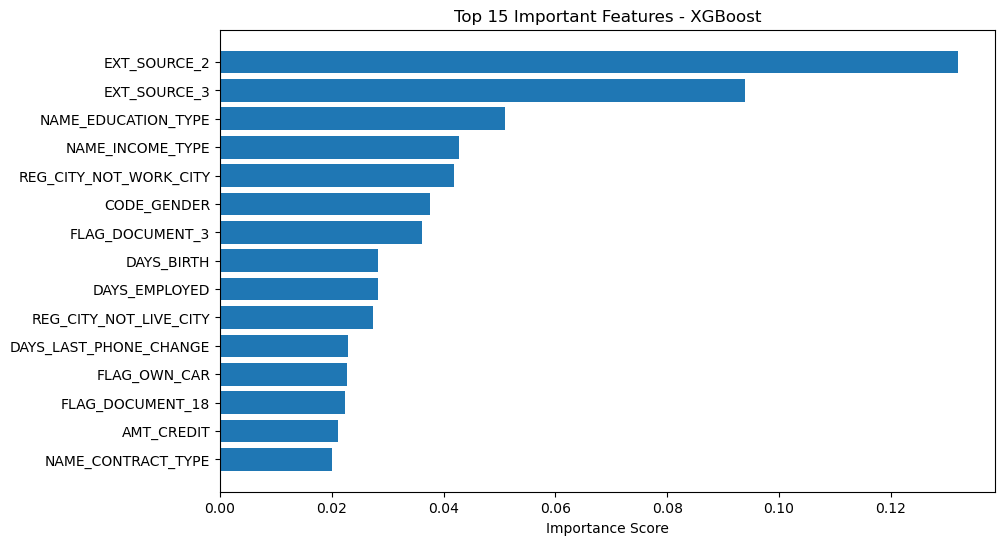

In [95]:
import pandas as pd
import matplotlib.pyplot as plt

feature_importance = pd.DataFrame({
    'Feature': xtrain.columns,
    'Importance': best_xgb.feature_importances_
}).sort_values(by='Importance', ascending=False)

print(feature_importance.head(20))

plt.figure(figsize=(10,6))
plt.barh(feature_importance['Feature'].head(15), feature_importance['Importance'].head(15))
plt.gca().invert_yaxis()
plt.title("Top 15 Important Features - XGBoost")
plt.xlabel("Importance Score")
plt.show()

### IMPROVE RECALL

In [96]:
scale_pos_weight = (ytrain == 0).sum() / (ytrain == 1).sum()

from xgboost import XGBClassifier

xgb_model = XGBClassifier(
    scale_pos_weight=scale_pos_weight,
    eval_metric='logloss',
    random_state=42
)

In [97]:
import joblib

joblib.dump(best_xgb, 'best_xgb_model.pkl')

['best_xgb_model.pkl']

In [98]:
import joblib

loaded_model = joblib.load('best_xgb_model.pkl')
print("Model loaded successfully")

Model loaded successfully


In [99]:
import os
print(os.getcwd())

/Users/arunpc/Portfolio/Machine Learning/Home Credit Default Risk Prediction
